# ETAPE 1 - Préparation, enrichissement et nettoyage des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
application_test = pd.read_csv('data_brut/application_test.csv')
application_train = pd.read_csv('data_brut/application_train.csv')
bureau = pd.read_csv('data_brut/bureau.csv')
bureau_balance = pd.read_csv('data_brut/bureau_balance.csv')
credit_card_balance = pd.read_csv('data_brut/credit_card_balance.csv')
HomeCredit_columns_description = pd.read_csv('data_brut/HomeCredit_columns_description.csv', encoding='latin1')
installments_payments = pd.read_csv('data_brut/installments_payments.csv')
POS_CASH_balance = pd.read_csv('data_brut/POS_CASH_balance.csv')
previous_application = pd.read_csv('data_brut/previous_application.csv')
sample_submission = pd.read_csv('data_brut/sample_submission.csv')

--------------------------------------------------------------------------------------------------------------

## I. Explication des datasets

1. **application_train.csv / application_test.csv**

Contiennent les informations principales sur les clients : âge, revenu, type de contrat, dépenses, etc.

***Train*** contient la variable cible TARGET (0 = remboursement, 1 = défaut).

***Test*** est la table sur laquelle tu dois faire tes prédictions.

2. **bureau.csv**

Historique de tous les crédits précédents du client dans d’autres institutions financières.

Une ligne = un crédit.

Contient : montant, durée, type de crédit, statut actuel, etc.

3. **bureau_balance.csv**

Historique mensuel de chaque crédit auprès d'autres institutions financières.

Une ligne = un mois d’un crédit.

Contient : SK_ID_BUREAU, mois du crédit, ***statut (C = payé à temps, X = aucun paiement, 0-5 = retard en mois).***

4. **POS_CASH_balance.csv**

Historique des prêts du client auprès de HomeCredit (cas échéant)

Une ligne = un mois d’un prêt en cours.

Contient : solde restant, retard de paiement, etc.

5. **credit_card_balance.csv**

Historique des cartes de crédit du client auprès de HomeCredit.

Une ligne = un mois d’utilisation d’une carte.

Contient : solde, montant dû, montant payé, retard, etc.

6. **installments_payments.csv**

Historique des paiements mensuels de crédits (prêts personnels) auprès de HomeCredit.

Une ligne = un paiement.

Contient : montant prévu, montant payé, retard de paiement, etc.

7. **HomeCredit_columns_description.csv**
  
Description des colonnes de HomeCredit

8. **sample_submission.csv**

Echantillon de données pour la soumission

*********************************************************************************************************

## II. Fusion des datasets

**Fusion attendue**

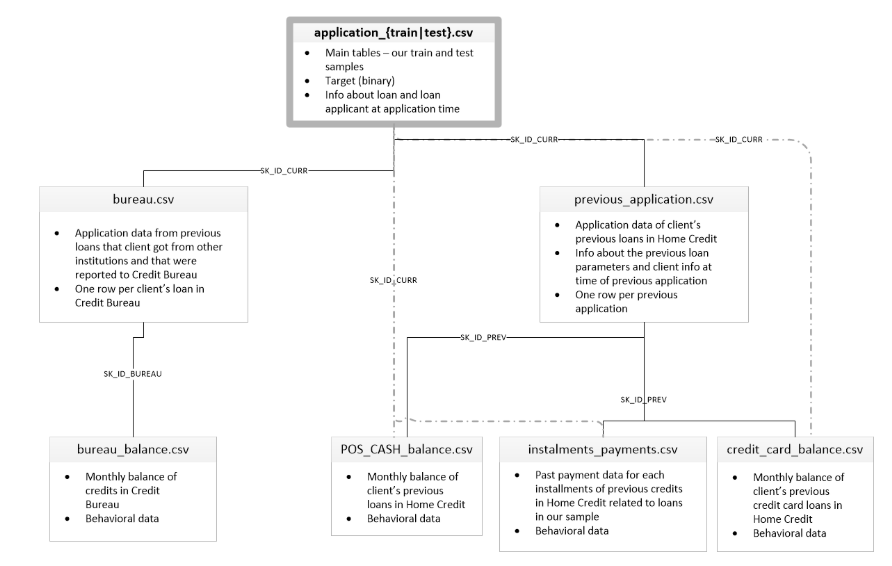

### A- Aggrégation et fusion des données liées au crédit extérieur à HomeCredit avec les données train et test

- Création d'un dataframe bureau_balance regroupé par client selon le nombre de mois et la moyenne du type de credit

In [3]:
'''
bb_by_status_mean = bureau_balance.groupby("SK_ID_BUREAU").agg(
    months_count=("MONTHS_BALANCE", "count"),
    status_mean_c=("STATUS", lambda x: (x == 'C').mean()), 
    status_mean_0=("STATUS", lambda x: (x == '0').mean()),
    status_mean_1=("STATUS", lambda x: (x == '1').mean()),
    status_mean_2=("STATUS", lambda x: (x == '2').mean()),
    status_mean_3=("STATUS", lambda x: (x == '3').mean()),
    status_mean_4=("STATUS", lambda x: (x == '4').mean()),
    status_mean_5=("STATUS", lambda x: (x == '5').mean()),
    status_mean_X=("STATUS", lambda x: (x == 'X').mean()) 
).reset_index()
'''

'\nbb_by_status_mean = bureau_balance.groupby("SK_ID_BUREAU").agg(\n    months_count=("MONTHS_BALANCE", "count"),\n    status_mean_c=("STATUS", lambda x: (x == \'C\').mean()), \n    status_mean_0=("STATUS", lambda x: (x == \'0\').mean()),\n    status_mean_1=("STATUS", lambda x: (x == \'1\').mean()),\n    status_mean_2=("STATUS", lambda x: (x == \'2\').mean()),\n    status_mean_3=("STATUS", lambda x: (x == \'3\').mean()),\n    status_mean_4=("STATUS", lambda x: (x == \'4\').mean()),\n    status_mean_5=("STATUS", lambda x: (x == \'5\').mean()),\n    status_mean_X=("STATUS", lambda x: (x == \'X\').mean()) \n).reset_index()\n'

Vu le temps de traitement, il est préférable de sauvegarder le dataframe résultant pour une utilisation ultérieure et désactiver la ligne de code pour réduire le temps de prochaine compilation globale

In [4]:
# bb_by_status_mean.to_csv('bureau_balance_by_status_mean.csv', index=False)

In [5]:
bb_by_status_mean = pd.read_csv('data/bureau_balance_by_status_mean.csv')

In [6]:
bb_by_status_mean.shape

(817395, 10)

In [7]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


Jointure des données bureau avec les données bureau balance aggrégées ci-dessus via bb_by_status_mean

In [8]:
bureau_complete = bureau.merge(bb_by_status_mean, on='SK_ID_BUREAU', how='left')

In [9]:
bureau_complete.shape

(1716428, 26)

In [10]:
bureau_complete.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,...,AMT_ANNUITY,months_count,status_mean_c,status_mean_0,status_mean_1,status_mean_2,status_mean_3,status_mean_4,status_mean_5,status_mean_X
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
bureau_complete.isna().sum()

SK_ID_CURR                      0
SK_ID_BUREAU                    0
CREDIT_ACTIVE                   0
CREDIT_CURRENCY                 0
DAYS_CREDIT                     0
CREDIT_DAY_OVERDUE              0
DAYS_CREDIT_ENDDATE        105553
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_MAX_OVERDUE    1124488
CNT_CREDIT_PROLONG              0
AMT_CREDIT_SUM                 13
AMT_CREDIT_SUM_DEBT        257669
AMT_CREDIT_SUM_LIMIT       591780
AMT_CREDIT_SUM_OVERDUE          0
CREDIT_TYPE                     0
DAYS_CREDIT_UPDATE              0
AMT_ANNUITY               1226791
months_count               942074
status_mean_c              942074
status_mean_0              942074
status_mean_1              942074
status_mean_2              942074
status_mean_3              942074
status_mean_4              942074
status_mean_5              942074
status_mean_X              942074
dtype: int64

Chaque SK_ID_BUREAU dans bureau correspond à un crédit passé du client chez un autre fournisseur.

Le dataset bureau_balance contient l’historique mensuel des paiements pour ces crédits.

**Cas où SK_ID_BUREAU existe dans bureau mais pas dans bureau_balance (les valeurs NaN sur les 9 dernières colonnes) :**

Le crédit est très récent et aucun mois n’a encore été enregistré.

Il manque des données pour ce crédit dans la base bureau_balance.

Le crédit a été annulé ou clôturé avant d’avoir des enregistrements mensuels.

In [12]:
# Nombre total de crédits dans bureau
total_credits = bureau['SK_ID_BUREAU'].nunique()

# Nombre de crédits de bureau présents dans bureau_balance
credits_in_balance = bureau_balance['SK_ID_BUREAU'].nunique()

# Nombre et pourcentage de crédits absents de bureau_balance
missing_credits = total_credits - credits_in_balance
missing_percent = missing_credits / total_credits * 100

print(f"Crédits dans bureau : {total_credits}")
print(f"Crédits présents dans bureau_balance : {credits_in_balance}")
print(f"Crédits manquants dans bureau_balance : {missing_credits} ({missing_percent:.2f}%)")


Crédits dans bureau : 1716428
Crédits présents dans bureau_balance : 817395
Crédits manquants dans bureau_balance : 899033 (52.38%)


Jointure avec les données de train

In [13]:
bureau_complete.columns

Index(['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY',
       'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
       'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
       'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
       'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE',
       'AMT_ANNUITY', 'months_count', 'status_mean_c', 'status_mean_0',
       'status_mean_1', 'status_mean_2', 'status_mean_3', 'status_mean_4',
       'status_mean_5', 'status_mean_X'],
      dtype='object')

In [14]:
bureau_complete.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,...,AMT_ANNUITY,months_count,status_mean_c,status_mean_0,status_mean_1,status_mean_2,status_mean_3,status_mean_4,status_mean_5,status_mean_X
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


On aggrège pour avoir les données uniquement par individus (SK_ID_CURR)

In [15]:
bureau_complete.dtypes.sort_values()

SK_ID_CURR                  int64
SK_ID_BUREAU                int64
DAYS_CREDIT                 int64
CREDIT_DAY_OVERDUE          int64
CNT_CREDIT_PROLONG          int64
DAYS_CREDIT_UPDATE          int64
status_mean_4             float64
status_mean_3             float64
status_mean_2             float64
status_mean_1             float64
status_mean_0             float64
status_mean_c             float64
months_count              float64
AMT_ANNUITY               float64
AMT_CREDIT_SUM_LIMIT      float64
AMT_CREDIT_SUM_OVERDUE    float64
status_mean_5             float64
AMT_CREDIT_SUM_DEBT       float64
AMT_CREDIT_SUM            float64
AMT_CREDIT_MAX_OVERDUE    float64
DAYS_ENDDATE_FACT         float64
DAYS_CREDIT_ENDDATE       float64
status_mean_X             float64
CREDIT_CURRENCY            object
CREDIT_ACTIVE              object
CREDIT_TYPE                object
dtype: object

In [16]:
# Pour les features numériques, on calcul le  min, max, mean, sum en fonction de ce qui est pertinent
bureau_feature = bureau_complete.groupby("SK_ID_CURR").agg(
    {"DAYS_CREDIT": ["mean", "min", "max"],
    "CREDIT_DAY_OVERDUE": ["mean", "max"],
    "DAYS_CREDIT_ENDDATE": ["mean", "min", "max"],
    "DAYS_ENDDATE_FACT": ["mean", "min", "max"],
    "AMT_CREDIT_MAX_OVERDUE": ["mean", "max"],
    "CNT_CREDIT_PROLONG": ["mean", "sum"],
    "AMT_CREDIT_SUM": ["mean", "sum", "max"],
    "AMT_CREDIT_SUM_DEBT": ["mean", "sum", "max"],
    "AMT_CREDIT_SUM_LIMIT": ["mean", "sum", "max"],
    "AMT_CREDIT_SUM_OVERDUE": ["mean", "sum", "max"],
    "DAYS_CREDIT_UPDATE": ["mean", "max"],
    "AMT_ANNUITY": ["mean", "sum"],
    "months_count": ["mean", "max"],
    "status_mean_c": ["mean"],
    "status_mean_0": ["mean"],
    "status_mean_1": ["mean"],
    "status_mean_2": ["mean"],
    "status_mean_3": ["mean"],
    "status_mean_4": ["mean"],
    "status_mean_5": ["mean"],
    "status_mean_X": ["mean"]
})

In [17]:
bureau_feature.head()

DAYS_CREDIT            CREDIT_DAY_OVERDUE     DAYS_CREDIT_ENDDATE  \
                   mean   min  max               mean max                mean   
SK_ID_CURR                                                                      
100001      -735.000000 -1572  -49                0.0   0           82.428571   
100002      -874.000000 -1437 -103                0.0   0         -349.000000   
100003     -1400.750000 -2586 -606                0.0   0         -544.500000   
100004      -867.000000 -1326 -408                0.0   0         -488.500000   
100005      -190.666667  -373  -62                0.0   0          439.333333   

                           DAYS_ENDDATE_FACT          ... months_count        \
               min     max              mean     min  ...         mean   max   
SK_ID_CURR                                            ...                      
100001     -1329.0  1778.0       -825.500000 -1328.0  ...    24.571429  52.0   
100002     -1072.0   780.0       -697.500000 -1185.0  ...    13.750000  22.0   
100003     -2434.0  1216.0      -1097.333333 -2131.0  ...          NaN   NaN   
100004      -595.0  -382.0       -532.500000  -683.0  ...          NaN   NaN   
100005      -128.0  1324.0       -123.000000  -123.0  ...     7.000000  13.0   

           status_mean_c status_mean_0 status_mean_1 status_mean_2  \
                    mean          mean          mean          mean   
SK_ID_CURR                                                           
100001          0.441240      0.336651      0.007519           0.0   
100002          0.175426      0.406960      0.255682           0.0   
100003               NaN           NaN           NaN           NaN   
100004               NaN           NaN           NaN           NaN   
100005          0.128205      0.735043      0.000000           0.0   

           status_mean_3 status_mean_4 status_mean_5 status_mean_X  
                    mean          mean          mean          mean  
SK_ID_CURR                                                          
100001               0.0           0.0           0.0      0.214590  
100002               0.0           0.0           0.0      0.161932  
100003               NaN           NaN           NaN           NaN  
100004               NaN           NaN           NaN           NaN  
100005               0.0           0.0           0.0      0.136752  

[5 rows x 41 columns]

In [18]:
# On applatit les noms de colonnes (multi-index → single index)
bureau_feature.columns = ["_".join(col).strip() for col in bureau_feature.columns.values]
bureau_feature = bureau_feature.reset_index()

In [19]:
bureau_feature.head()

,SK_ID_CURR,DAYS_CREDIT_mean,DAYS_CREDIT_min,DAYS_CREDIT_max,CREDIT_DAY_OVERDUE_mean,CREDIT_DAY_OVERDUE_max,DAYS_CREDIT_ENDDATE_mean,DAYS_CREDIT_ENDDATE_min,DAYS_CREDIT_ENDDATE_max,DAYS_ENDDATE_FACT_mean,...,months_count_mean,months_count_max,status_mean_c_mean,status_mean_0_mean,status_mean_1_mean,status_mean_2_mean,status_mean_3_mean,status_mean_4_mean,status_mean_5_mean,status_mean_X_mean
0,100001,-735.000000,-1572,-49,0.0,0,82.428571,-1329.0,1778.0,-825.500000,...,24.571429,52.0,0.441240,0.336651,0.007519,0.0,0.0,0.0,0.0,0.214590
1,100002,-874.000000,-1437,-103,0.0,0,-349.000000,-1072.0,780.0,-697.500000,...,13.750000,22.0,0.175426,0.406960,0.255682,0.0,0.0,0.0,0.0,0.161932
2,100003,-1400.750000,-2586,-606,0.0,0,-544.500000,-2434.0,1216.0,-1097.333333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100004,-867.000000,-1326,-408,0.0,0,-488.500000,-595.0,-382.0,-532.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100005,-190.666667,-373,-62,0.0,0,439.333333,-128.0,1324.0,-123.000000,...,7.000000,13.0,0.128205,0.735043,0.000000,0.0,0.0,0.0,0.0,0.136752


Pour les features catégorielles, on encode en onehotencoder

In [20]:
# Pour CREDIT_ACTIVE
credit_active_dummies = pd.get_dummies(bureau_complete["CREDIT_ACTIVE"], prefix="CREDIT_ACTIVE")
credit_active_dummies["SK_ID_CURR"] = bureau_complete["SK_ID_CURR"]
credit_active_features = credit_active_dummies.groupby("SK_ID_CURR").sum().reset_index()
# On fusionne avec bureau_feature
bureau_feature = bureau_feature.merge(credit_active_features, on="SK_ID_CURR", how="left")

In [21]:
# Pour CREDIT_TYPE
credit_type_dummies = pd.get_dummies(bureau_complete["CREDIT_TYPE"], prefix="CREDIT_TYPE")
# On ajoute la colonne SK_ID_CURR pour regrouper les features par client
credit_type_dummies["SK_ID_CURR"] = bureau_complete["SK_ID_CURR"]
# On regroupe les features par SK_ID_CURR en faisant la somme des trues 
credit_type_features = credit_type_dummies.groupby("SK_ID_CURR").sum().reset_index()
# On fusionne avec bureau_feature
bureau_feature = bureau_feature.merge(credit_type_features, on="SK_ID_CURR", how="left")


In [22]:
# Pour CREDIT_CURRENCY
credit_currency_dummies = pd.get_dummies(bureau_complete["CREDIT_CURRENCY"], prefix="CREDIT_CURRENCY")
# On ajoute la colonne SK_ID_CURR pour regrouper les features par client
credit_currency_dummies["SK_ID_CURR"] = bureau_complete["SK_ID_CURR"]
# On regroupe les features par SK_ID_CURR en faisant la somme des trues 
credit_currency_features = credit_currency_dummies.groupby("SK_ID_CURR").sum().reset_index()
# On fusionne avec bureau_feature
bureau_feature = bureau_feature.merge(credit_currency_features, on="SK_ID_CURR", how="left")

In [23]:
bureau_feature.head()

,SK_ID_CURR,DAYS_CREDIT_mean,DAYS_CREDIT_min,DAYS_CREDIT_max,CREDIT_DAY_OVERDUE_mean,CREDIT_DAY_OVERDUE_max,DAYS_CREDIT_ENDDATE_mean,DAYS_CREDIT_ENDDATE_min,DAYS_CREDIT_ENDDATE_max,DAYS_ENDDATE_FACT_mean,...,CREDIT_TYPE_Loan for working capital replenishment,CREDIT_TYPE_Microloan,CREDIT_TYPE_Mobile operator loan,CREDIT_TYPE_Mortgage,CREDIT_TYPE_Real estate loan,CREDIT_TYPE_Unknown type of loan,CREDIT_CURRENCY_currency 1,CREDIT_CURRENCY_currency 2,CREDIT_CURRENCY_currency 3,CREDIT_CURRENCY_currency 4
0,100001,-735.000000,-1572,-49,0.0,0,82.428571,-1329.0,1778.0,-825.500000,...,0,0,0,0,0,0,7,0,0,0
1,100002,-874.000000,-1437,-103,0.0,0,-349.000000,-1072.0,780.0,-697.500000,...,0,0,0,0,0,0,8,0,0,0
2,100003,-1400.750000,-2586,-606,0.0,0,-544.500000,-2434.0,1216.0,-1097.333333,...,0,0,0,0,0,0,4,0,0,0
3,100004,-867.000000,-1326,-408,0.0,0,-488.500000,-595.0,-382.0,-532.500000,...,0,0,0,0,0,0,2,0,0,0
4,100005,-190.666667,-373,-62,0.0,0,439.333333,-128.0,1324.0,-123.000000,...,0,0,0,0,0,0,3,0,0,0


On fait la jointure avec le fichier de train et de test pour les enrichir 

In [24]:
train_merged = application_train.merge(bureau_feature, on="SK_ID_CURR", how="left")
test_merged = application_test.merge(bureau_feature, on="SK_ID_CURR", how="left")

In [25]:
train_merged

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CREDIT_TYPE_Loan for working capital replenishment,CREDIT_TYPE_Microloan,CREDIT_TYPE_Mobile operator loan,CREDIT_TYPE_Mortgage,CREDIT_TYPE_Real estate loan,CREDIT_TYPE_Unknown type of loan,CREDIT_CURRENCY_currency 1,CREDIT_CURRENCY_currency 2,CREDIT_CURRENCY_currency 3,CREDIT_CURRENCY_currency 4
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### B- Aggrégation et fusion des données de prêt interne à HomeCredit avec les données train et test

In [26]:
application_train.shape, application_test.shape

((307511, 122), (48744, 121))

- Previous application

In [27]:
# Demande de prêt précédente auprès de HomeCredit
previous_application.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
previous_application.select_dtypes(include=['number']).columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'AMT_ANNUITY', 'AMT_APPLICATION',
       'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE',
       'HOUR_APPR_PROCESS_START', 'NFLAG_LAST_APPL_IN_DAY',
       'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY',
       'RATE_INTEREST_PRIVILEGED', 'DAYS_DECISION', 'SELLERPLACE_AREA',
       'CNT_PAYMENT', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE',
       'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION',
       'NFLAG_INSURED_ON_APPROVAL'],
      dtype='object')

In [29]:
previous_application.select_dtypes(include=['object']).columns

Index(['NAME_CONTRACT_TYPE', 'WEEKDAY_APPR_PROCESS_START',
       'FLAG_LAST_APPL_PER_CONTRACT', 'NAME_CASH_LOAN_PURPOSE',
       'NAME_CONTRACT_STATUS', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON',
       'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY',
       'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE',
       'NAME_SELLER_INDUSTRY', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION'],
      dtype='object')

In [30]:
num_cols = [
    'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT',
    'AMT_GOODS_PRICE', 'HOUR_APPR_PROCESS_START', 'RATE_DOWN_PAYMENT',
    'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'SELLERPLACE_AREA',
    'CNT_PAYMENT', 'DAYS_DECISION', 'DAYS_FIRST_DRAWING',
    'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE',
    'DAYS_TERMINATION'
]

cat_cols = [
    'NAME_CONTRACT_TYPE', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS',
    'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE',
    'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO',
    'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'NAME_SELLER_INDUSTRY',
    'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION'
]


In [31]:
agg_dict = {}

# Numériques → stats
for col in num_cols:
    agg_dict[col] = ['mean', 'min', 'max', 'std']

# Catégorielles → mode
for col in cat_cols:
    agg_dict[col] = (lambda x: x.mode()[0] if not x.mode().empty else np.nan)

# Comptage des prêts
agg_dict['SK_ID_PREV'] = 'count'


In [32]:
# On regroupe les données par SK_ID_CURR et on applique les agrégations définies
# On déscative cette ligne au vu de la durée d'exécution
'''previous_application_agg = previous_application.groupby("SK_ID_CURR").agg(agg_dict)'''

'previous_application_agg = previous_application.groupby("SK_ID_CURR").agg(agg_dict)'

In [33]:
# On applatit les noms de colonnes (multi-index → single index)
'''
previous_application_agg.columns = ["_".join(col).strip() for col in previous_application_agg.columns.values]
previous_application_agg = previous_application_agg.reset_index()'''

'\nprevious_application_agg.columns = ["_".join(col).strip() for col in previous_application_agg.columns.values]\nprevious_application_agg = previous_application_agg.reset_index()'

In [34]:
# On enregistre le résultat dans un fichier CSV pour une utilisation ultérieure
# On désactive cette ligne pour éviter de réécrire le fichier à chaque exécution
'''
previous_application_agg.to_csv('previous_application_agg.csv', index=True)'''

"\nprevious_application_agg.to_csv('previous_application_agg.csv', index=True)"

In [35]:
previous_application_agg = pd.read_csv('data/previous_application_agg.csv', index_col=0)

In [36]:
previous_application_agg.head()

,SK_ID_CURR,AMT_ANNUITY_mean,AMT_ANNUITY_min,AMT_ANNUITY_max,AMT_ANNUITY_std,AMT_APPLICATION_mean,AMT_APPLICATION_min,AMT_APPLICATION_max,AMT_APPLICATION_std,AMT_CREDIT_mean,...,NAME_TYPE_SUITE_<lambda>,NAME_CLIENT_TYPE_<lambda>,NAME_GOODS_CATEGORY_<lambda>,NAME_PORTFOLIO_<lambda>,NAME_PRODUCT_TYPE_<lambda>,CHANNEL_TYPE_<lambda>,NAME_SELLER_INDUSTRY_<lambda>,NAME_YIELD_GROUP_<lambda>,PRODUCT_COMBINATION_<lambda>,SK_ID_PREV_count
0,100001,3951.000,3951.000,3951.000,NaN,24835.50,24835.5,24835.5,NaN,23787.00,...,Family,Refreshed,Mobile,POS,XNA,Country-wide,Connectivity,high,POS mobile with interest,1
1,100002,9251.775,9251.775,9251.775,NaN,179055.00,179055.0,179055.0,NaN,179055.00,...,NaN,New,Vehicles,POS,XNA,Stone,Auto technology,low_normal,POS other with interest,1
2,100003,56553.990,6737.310,98356.995,46332.557777,435436.50,68809.5,900000.0,424161.620549,484191.00,...,Family,Refreshed,Consumer Electronics,POS,XNA,Country-wide,Consumer electronics,middle,Cash X-Sell: low,3
3,100004,5357.250,5357.250,5357.250,NaN,24282.00,24282.0,24282.0,NaN,20106.00,...,Unaccompanied,New,Mobile,POS,XNA,Regional / Local,Connectivity,middle,POS mobile without interest,1
4,100005,4813.200,4813.200,4813.200,NaN,22308.75,0.0,44617.5,31549.336810,20076.75,...,NaN,New,Mobile,POS,XNA,Country-wide,Connectivity,XNA,Cash,2


- POS CASH Balance

In [37]:
num_cols = [
    'MONTHS_BALANCE','CNT_INSTALMENT','CNT_INSTALMENT_FUTURE','SK_DPD','SK_DPD_DEF'
]

cat_cols = [
    'NAME_CONTRACT_STATUS'
]

In [38]:
agg_dict = {}

# Numériques → stats
for col in num_cols:
    agg_dict[col] = ['mean', 'min', 'max', 'std']

# Catégorielles → mode
for col in cat_cols:
    agg_dict[col] = (lambda x: x.mode()[0] if not x.mode().empty else np.nan)

# Comptage des prêts
agg_dict['SK_ID_PREV'] = 'count'

In [39]:
POS_CASH_balance_agg = POS_CASH_balance.groupby("SK_ID_CURR").agg(agg_dict)

In [40]:
POS_CASH_balance_agg.columns = ["_".join(col).strip() for col in POS_CASH_balance_agg.columns.values]
POS_CASH_balance_agg = POS_CASH_balance_agg.reset_index()

In [41]:
POS_CASH_balance_agg.rename(columns={'NAME_CONTRACT_STATUS_<lambda>': 'NAME_CONTRACT_STATUS_most_use'}, inplace=True)

In [42]:
POS_CASH_balance_agg.head()

,SK_ID_CURR,MONTHS_BALANCE_mean,MONTHS_BALANCE_min,MONTHS_BALANCE_max,MONTHS_BALANCE_std,CNT_INSTALMENT_mean,CNT_INSTALMENT_min,CNT_INSTALMENT_max,CNT_INSTALMENT_std,CNT_INSTALMENT_FUTURE_mean,...,SK_DPD_mean,SK_DPD_min,SK_DPD_max,SK_DPD_std,SK_DPD_DEF_mean,SK_DPD_DEF_min,SK_DPD_DEF_max,SK_DPD_DEF_std,NAME_CONTRACT_STATUS_most_use,SK_ID_PREV_count
0,100001,-72.555556,-96,-53,20.863312,4.000000,4.0,4.0,0.000000,1.444444,...,0.777778,0,7,2.333333,0.777778,0,7,2.333333,Active,9
1,100002,-10.000000,-19,-1,5.627314,24.000000,24.0,24.0,0.000000,15.000000,...,0.000000,0,0,0.000000,0.000000,0,0,0.000000,Active,19
2,100003,-43.785714,-77,-18,24.640162,10.107143,6.0,12.0,2.806597,5.785714,...,0.000000,0,0,0.000000,0.000000,0,0,0.000000,Active,28
3,100004,-25.500000,-27,-24,1.290994,3.750000,3.0,4.0,0.500000,2.250000,...,0.000000,0,0,0.000000,0.000000,0,0,0.000000,Active,4
4,100005,-20.000000,-25,-15,3.316625,11.700000,9.0,12.0,0.948683,7.200000,...,0.000000,0,0,0.000000,0.000000,0,0,0.000000,Active,11


- Installment payments

In [43]:
installments_payments.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION',
       'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT',
       'AMT_INSTALMENT', 'AMT_PAYMENT'],
      dtype='object')

In [44]:
# On crée de nouvelles features à partir des paiements d'installments

df = installments_payments.copy()

# Retard (jours de retard : positif si paiement en retard, négatif si en avance)
df["DAYS_LATE"] = df["DAYS_ENTRY_PAYMENT"] - df["DAYS_INSTALMENT"]

# Différence entre montant attendu et payé
df["AMT_DIFF"] = df["AMT_INSTALMENT"] - df["AMT_PAYMENT"]

# Ratio de paiement (1 = payé exactement, <1 = sous-paiement, >1 = surpaiement)
df["PAYMENT_RATIO"] = df["AMT_PAYMENT"] / df["AMT_INSTALMENT"]

In [45]:
installments_agg = df.groupby("SK_ID_CURR").agg({
    "SK_ID_PREV": "nunique",   # nb de prêts avec échéances
    "NUM_INSTALMENT_NUMBER": "max",  # nombre max d'échéances
    "AMT_INSTALMENT": ["sum", "mean"],
    "AMT_PAYMENT": ["sum", "mean"],
    "AMT_DIFF": ["mean", "max", "min"],
    "PAYMENT_RATIO": ["mean"],
    "DAYS_LATE": ["mean", "max", "min"]
})


In [46]:
installments_agg.columns = [
    f"{col[0]}_{col[1]}" for col in installments_agg.columns
]
installments_agg = installments_agg.reset_index()


In [47]:
installments_agg.head()

,SK_ID_CURR,SK_ID_PREV_nunique,NUM_INSTALMENT_NUMBER_max,AMT_INSTALMENT_sum,AMT_INSTALMENT_mean,AMT_PAYMENT_sum,AMT_PAYMENT_mean,AMT_DIFF_mean,AMT_DIFF_max,AMT_DIFF_min,PAYMENT_RATIO_mean,DAYS_LATE_mean,DAYS_LATE_max,DAYS_LATE_min
0,100001,2,4,41195.925,5885.132143,41195.925,5885.132143,0.0,0.0,0.0,1.0,-7.285714,11.0,-36.0
1,100002,1,19,219625.695,11559.247105,219625.695,11559.247105,0.0,0.0,0.0,1.0,-20.421053,-12.0,-31.0
2,100003,3,12,1618864.650,64754.586000,1618864.650,64754.586000,0.0,0.0,0.0,1.0,-7.160000,-1.0,-14.0
3,100004,1,3,21288.465,7096.155000,21288.465,7096.155000,0.0,0.0,0.0,1.0,-7.666667,-3.0,-11.0
4,100005,1,9,56161.845,6240.205000,56161.845,6240.205000,0.0,0.0,0.0,1.0,-23.555556,1.0,-37.0


- Credit cart balance

In [48]:
credit_card_balance.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE',
       'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT',
       'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT',
       'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY',
       'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT',
       'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE',
       'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT',
       'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT',
       'CNT_INSTALMENT_MATURE_CUM', 'NAME_CONTRACT_STATUS', 'SK_DPD',
       'SK_DPD_DEF'],
      dtype='object')

In [49]:
# Création de nouvelles features à partir du solde de la carte de crédit

df = credit_card_balance.copy()

# Ratio solde / limite de crédit (taux d’utilisation)
df["BALANCE_LIMIT_RATIO"] = df["AMT_BALANCE"] / df["AMT_CREDIT_LIMIT_ACTUAL"]

# Ratio paiement effectué vs dû
df["PAYMENT_RATIO"] = df["AMT_PAYMENT_CURRENT"] / (df["AMT_INST_MIN_REGULARITY"] + 1e-5)

# Montant utilisé vs limite
df["DRAWINGS_LIMIT_RATIO"] = df["AMT_DRAWINGS_CURRENT"] / (df["AMT_CREDIT_LIMIT_ACTUAL"] + 1e-5)


In [50]:
credit_card_agg = df.groupby("SK_ID_CURR").agg({
    "SK_ID_PREV": "nunique",  # nombre de cartes
    "AMT_BALANCE": ["mean", "max"],
    "AMT_CREDIT_LIMIT_ACTUAL": ["mean", "max"],
    "AMT_DRAWINGS_CURRENT": ["mean", "max", "sum"],
    "AMT_DRAWINGS_ATM_CURRENT": ["mean", "sum"],
    "AMT_DRAWINGS_POS_CURRENT": ["mean", "sum"],
    "AMT_PAYMENT_CURRENT": ["mean", "max", "sum"],
    "AMT_TOTAL_RECEIVABLE": ["mean", "max"],
    "CNT_DRAWINGS_CURRENT": ["mean", "sum"],
    "CNT_DRAWINGS_ATM_CURRENT": ["mean", "sum"],
    "CNT_DRAWINGS_POS_CURRENT": ["mean", "sum"],
    "SK_DPD": ["mean", "max"],          # jours de retard
    "SK_DPD_DEF": ["mean", "max"],      # défauts graves
    "BALANCE_LIMIT_RATIO": ["mean", "max"],
    "PAYMENT_RATIO": ["mean"],
    "DRAWINGS_LIMIT_RATIO": ["mean"]
})


In [51]:
credit_card_agg.columns = [
    f"{col[0]}_{col[1]}" for col in credit_card_agg.columns
]
credit_card_agg = credit_card_agg.reset_index()


In [52]:
credit_card_agg.head()

,SK_ID_CURR,SK_ID_PREV_nunique,AMT_BALANCE_mean,AMT_BALANCE_max,AMT_CREDIT_LIMIT_ACTUAL_mean,AMT_CREDIT_LIMIT_ACTUAL_max,AMT_DRAWINGS_CURRENT_mean,AMT_DRAWINGS_CURRENT_max,AMT_DRAWINGS_CURRENT_sum,AMT_DRAWINGS_ATM_CURRENT_mean,...,CNT_DRAWINGS_POS_CURRENT_mean,CNT_DRAWINGS_POS_CURRENT_sum,SK_DPD_mean,SK_DPD_max,SK_DPD_DEF_mean,SK_DPD_DEF_max,BALANCE_LIMIT_RATIO_mean,BALANCE_LIMIT_RATIO_max,PAYMENT_RATIO_mean,DRAWINGS_LIMIT_RATIO_mean
0,100006,1,0.000000,0.00,270000.000000,270000,0.000000,0.0,0.0,NaN,...,NaN,0.0,0.000000,0,0.000000,0,0.000000,0.00000,NaN,0.000000
1,100011,1,54482.111149,189000.00,164189.189189,180000,2432.432432,180000.0,180000.0,2432.432432,...,0.0,0.0,0.000000,0,0.000000,0,0.302678,1.05000,3.086877e+07,0.013514
2,100013,1,18159.919219,161420.22,131718.750000,157500,5953.125000,157500.0,571500.0,6350.000000,...,0.0,0.0,0.010417,1,0.010417,1,0.115301,1.02489,2.652497e+07,0.037798
3,100021,1,0.000000,0.00,675000.000000,675000,0.000000,0.0,0.0,NaN,...,NaN,0.0,0.000000,0,0.000000,0,0.000000,0.00000,NaN,0.000000
4,100023,1,0.000000,0.00,135000.000000,225000,0.000000,0.0,0.0,NaN,...,NaN,0.0,0.000000,0,0.000000,0,0.000000,0.00000,NaN,0.000000


jointure avec train

In [53]:
for df in [previous_application_agg, POS_CASH_balance_agg, installments_agg, credit_card_agg]:
    print(df.columns[0])  # doit être SK_ID_CURR


SK_ID_CURR
SK_ID_CURR
SK_ID_CURR
SK_ID_CURR


In [54]:
application_train.shape

(307511, 122)

In [55]:
application_train = application_train.merge(previous_application_agg, on="SK_ID_CURR", how="left")

In [56]:
application_train = application_train.merge(POS_CASH_balance_agg, on="SK_ID_CURR",how="left")

In [57]:
application_train = application_train.merge(installments_agg, on="SK_ID_CURR", how="left")

In [58]:
application_train = application_train.merge(credit_card_agg, on="SK_ID_CURR", how="left")

In [59]:
application_train.shape

(307511, 271)

Jointure avec test

In [60]:
application_test.shape

(48744, 121)

In [61]:
application_test = application_test.merge(previous_application_agg, on="SK_ID_CURR", how="left")

In [62]:
application_test = application_test.merge(POS_CASH_balance_agg, on="SK_ID_CURR",how="left")

In [63]:
application_test = application_test.merge(installments_agg, on="SK_ID_CURR", how="left")

In [64]:
application_test = application_test.merge(credit_card_agg, on="SK_ID_CURR", how="left")

In [65]:
application_test.shape

(48744, 270)

# Exploration et nettoyage des données

## A- Pourçentage de chaque valeur target

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

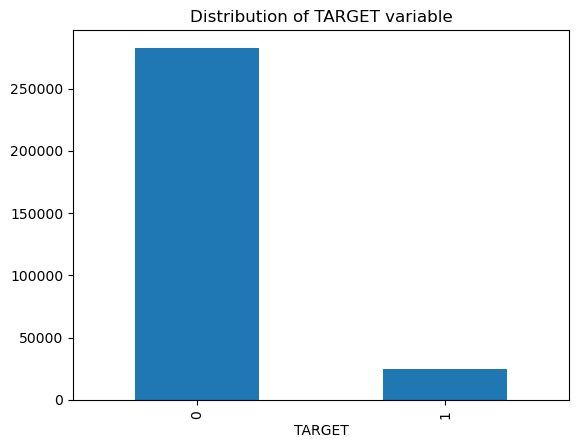

In [67]:
application_train['TARGET'].value_counts().plot(kind='bar', title='Distribution of TARGET variable')
plt.show()

Un gros déséquilibre entre les personnes qui ont payé leur dette et celle qui ne l'ont pas faite, nous allons y revenir plus tard

In [68]:
application_train.select_dtypes(include=['number'])

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,CNT_DRAWINGS_POS_CURRENT_mean,CNT_DRAWINGS_POS_CURRENT_sum,SK_DPD_mean_y,SK_DPD_max_y,SK_DPD_DEF_mean_y,SK_DPD_DEF_max_y,BALANCE_LIMIT_RATIO_mean,BALANCE_LIMIT_RATIO_max,PAYMENT_RATIO_mean_y,DRAWINGS_LIMIT_RATIO_mean
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,0,157500.0,254700.0,27558.0,225000.0,0.032561,-9327,-236,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,0,72000.0,269550.0,12001.5,225000.0,0.025164,-20775,365243,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,0,153000.0,677664.0,29979.0,585000.0,0.005002,-14966,-7921,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307509,456254,1,0,171000.0,370107.0,20205.0,319500.0,0.005313,-11961,-4786,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## B- Valeurs manquantes

- Pourçentage de valeur manquantes par colonne

In [69]:
application_train.isnull().mean().sort_values(ascending=False).head(25)

RATE_INTEREST_PRIVILEGED_std     0.999434
RATE_INTEREST_PRIMARY_std        0.999434
RATE_INTEREST_PRIMARY_max        0.985012
RATE_INTEREST_PRIMARY_mean       0.985012
RATE_INTEREST_PRIVILEGED_max     0.985012
RATE_INTEREST_PRIVILEGED_min     0.985012
RATE_INTEREST_PRIVILEGED_mean    0.985012
RATE_INTEREST_PRIMARY_min        0.985012
AMT_PAYMENT_CURRENT_max          0.801438
PAYMENT_RATIO_mean_y             0.801438
AMT_PAYMENT_CURRENT_mean         0.801438
AMT_DRAWINGS_POS_CURRENT_mean    0.801178
CNT_DRAWINGS_ATM_CURRENT_mean    0.801178
CNT_DRAWINGS_POS_CURRENT_mean    0.801178
AMT_DRAWINGS_ATM_CURRENT_mean    0.801178
BALANCE_LIMIT_RATIO_mean         0.721665
BALANCE_LIMIT_RATIO_max          0.719805
SK_ID_PREV_nunique_y             0.717392
AMT_BALANCE_mean                 0.717392
AMT_BALANCE_max                  0.717392
AMT_CREDIT_LIMIT_ACTUAL_mean     0.717392
AMT_CREDIT_LIMIT_ACTUAL_max      0.717392
AMT_DRAWINGS_CURRENT_sum         0.717392
AMT_DRAWINGS_CURRENT_mean        0

On va commencer par supprimer les colonnes ayant au moins 90% des valeurs manquantes 

In [70]:
# Seuil de tolérance pour les valeurs manquantes
threshold = 0.9  

# Calcul du pourcentage de valeurs manquantes
missing_ratio = application_train.isna().mean()

# Colonnes à supprimer
cols_to_drop = missing_ratio[missing_ratio > threshold].index

# Suppression des colonnes
application_train = application_train.drop(columns=cols_to_drop)

print(f"Colonnes supprimées (plus de {threshold*100:.0f}% de valeurs manquantes) :")
print(list(cols_to_drop))


Colonnes supprimées (plus de 90% de valeurs manquantes) :
['RATE_INTEREST_PRIMARY_mean', 'RATE_INTEREST_PRIMARY_min', 'RATE_INTEREST_PRIMARY_max', 'RATE_INTEREST_PRIMARY_std', 'RATE_INTEREST_PRIVILEGED_mean', 'RATE_INTEREST_PRIVILEGED_min', 'RATE_INTEREST_PRIVILEGED_max', 'RATE_INTEREST_PRIVILEGED_std']


In [71]:
application_test = application_test.drop(columns=cols_to_drop)

On renomme les colonnes

In [72]:
import re

# Renommer les colonnes qui finissent par _<lambda>
application_train.rename(
    columns=lambda col: re.sub(r"_<lambda>$", "_most_use", col),
    inplace=True
)

In [73]:
import re

# Renommer les colonnes qui finissent par _<lambda>
application_test.rename(
    columns=lambda col: re.sub(r"_<lambda>$", "_most_use", col),
    inplace=True
)

## C- Visualisation des valeurs manquantes avec missingno

In [74]:
pip install missingno

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



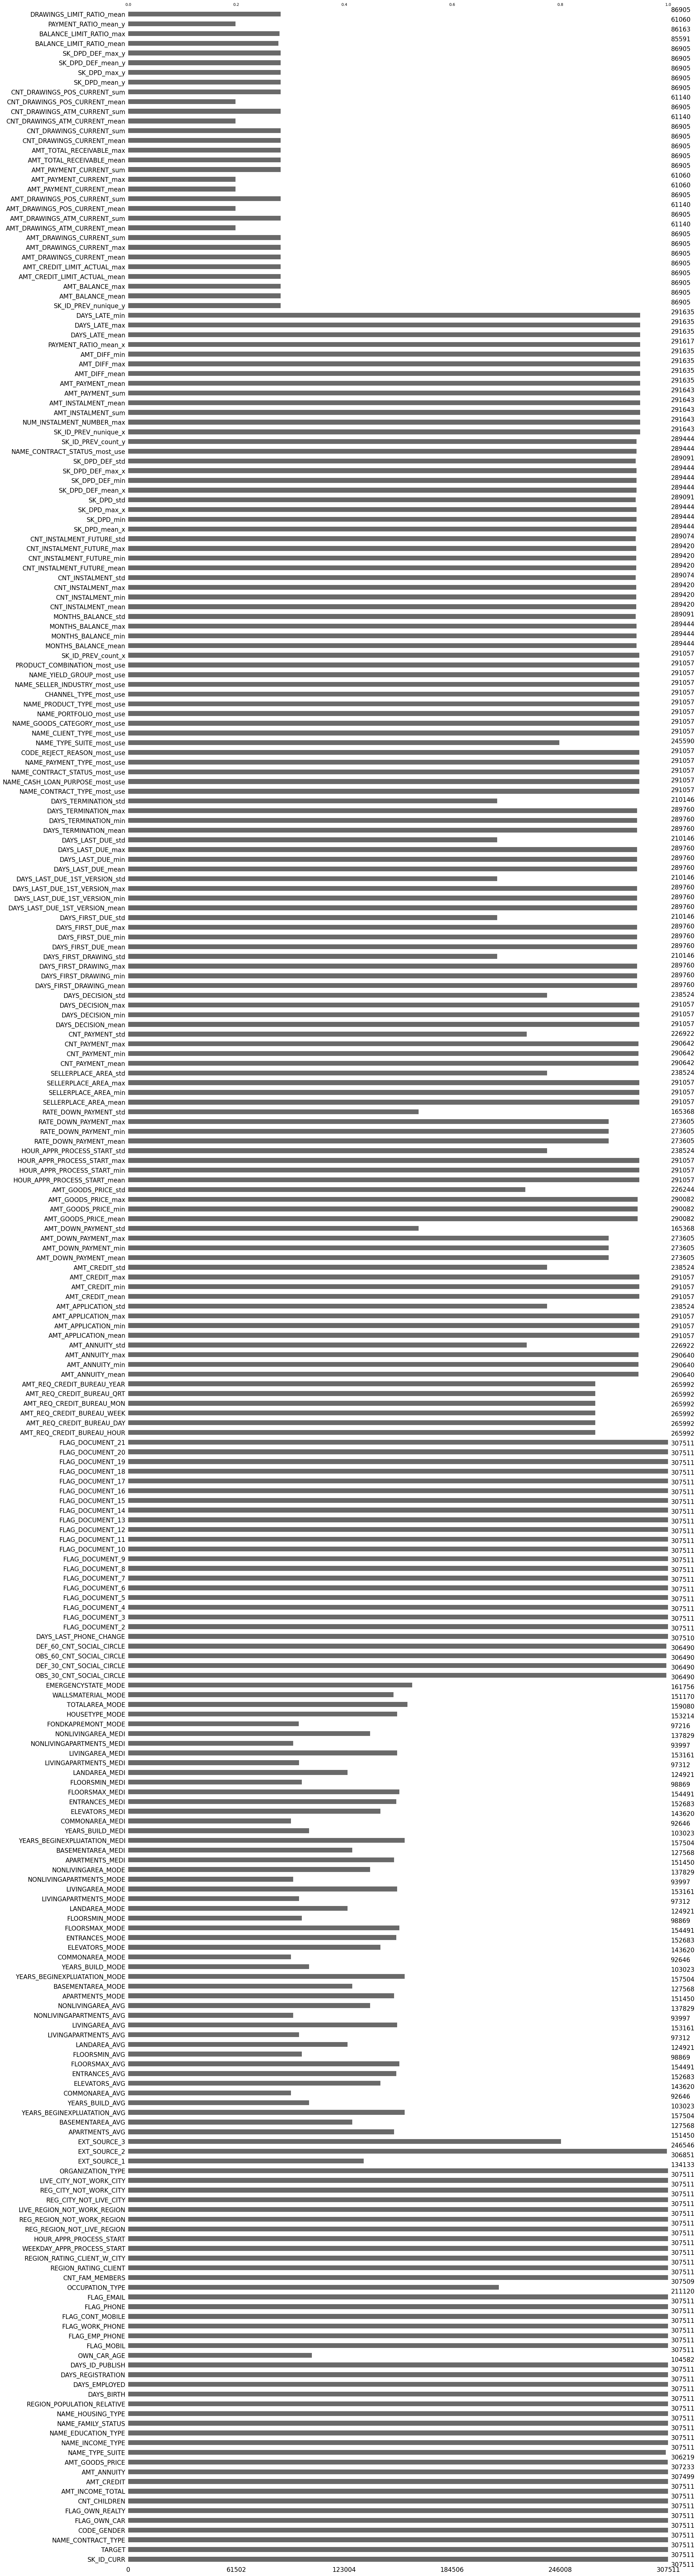

In [75]:
import missingno as msno
import matplotlib.pyplot as plt

# Diagramme de barres (valeurs manquantes par colonne)
msno.bar(application_train)
plt.show()


Plusieurs colonnes sont à supprimer au vu de ce missingno, 

Plus la barre de la colonne est longue, plus est contient des valeurs et à l'inverse elle a des valeurs manquantes

Vérifions quelques colonnes douteuses 

In [76]:
application_train[['TARGET','SK_DPD_mean_x', 'SK_DPD_mean_y', 'SK_DPD_DEF_mean_x', 'SK_DPD_DEF_mean_y', 'PAYMENT_RATIO_mean_x', 'PAYMENT_RATIO_mean_y']]

,TARGET,SK_DPD_mean_x,SK_DPD_mean_y,SK_DPD_DEF_mean_x,SK_DPD_DEF_mean_y,PAYMENT_RATIO_mean_x,PAYMENT_RATIO_mean_y
0,1,0.000000,NaN,0.000000,NaN,1.000000,NaN
1,0,0.000000,NaN,0.000000,NaN,1.000000,NaN
2,0,0.000000,NaN,0.000000,NaN,1.000000,NaN
3,0,0.000000,0.0,0.000000,0.0,1.000000,NaN
4,0,0.000000,NaN,0.000000,NaN,0.954545,NaN
...,...,...,...,...,...,...,...
307506,0,0.000000,NaN,0.000000,NaN,1.000000,NaN
307507,0,0.000000,NaN,0.000000,NaN,1.000000,NaN
307508,0,0.294118,NaN,0.294118,NaN,0.928571,NaN
307509,1,0.000000,NaN,0.000000,NaN,1.000000,NaN


Pour commencer on va supprimer toutes les colonne terminant par _y qui sont apparues lors des fusions des dataframes, le y apparaissait donc parce qu'il existait déjà une colonne avec le même nom (qui ont donc été automatiquement nomée avec un _x à la fin)

In [77]:
# Supprimer colonnes finissant par "_y" (issues des fusions de DataFrame)
cols_y = [col for col in application_train.columns if col.endswith("_y")]

# Regrouper et supprimer en une seule opération
cols_to_drop = cols_y
application_train = application_train.drop(columns=cols_to_drop)
application_test = application_test.drop(columns=cols_to_drop)

print(f"{len(cols_to_drop)} colonnes supprimées :")
print(cols_to_drop)


7 colonnes supprimées :
['SK_ID_PREV_count_y', 'SK_ID_PREV_nunique_y', 'SK_DPD_mean_y', 'SK_DPD_max_y', 'SK_DPD_DEF_mean_y', 'SK_DPD_DEF_max_y', 'PAYMENT_RATIO_mean_y']


In [78]:
# Renommer les colonnes qui finissent par "_x" sur train
application_train = application_train.rename(
    columns=lambda col: col[:-2] if col.endswith("_x") else col
)
# Renommer les colonnes qui finissent par "_x" sur test
application_test = application_test.rename(
    columns=lambda col: col[:-2] if col.endswith("_x") else col
)

print("Colonnes renommées (suppression du suffixe _x).")


Colonnes renommées (suppression du suffixe _x).


In [79]:
application_train.select_dtypes(include=['object']).apply(pd.Series.nunique, axis=0).sort_values(ascending=False)

ORGANIZATION_TYPE                  58
NAME_GOODS_CATEGORY_most_use       26
NAME_CASH_LOAN_PURPOSE_most_use    25
OCCUPATION_TYPE                    18
PRODUCT_COMBINATION_most_use       17
NAME_SELLER_INDUSTRY_most_use      11
CODE_REJECT_REASON_most_use         9
CHANNEL_TYPE_most_use               8
NAME_INCOME_TYPE                    8
NAME_TYPE_SUITE_most_use            7
WALLSMATERIAL_MODE                  7
NAME_CONTRACT_STATUS_most_use       7
WEEKDAY_APPR_PROCESS_START          7
NAME_TYPE_SUITE                     7
NAME_HOUSING_TYPE                   6
NAME_FAMILY_STATUS                  6
NAME_EDUCATION_TYPE                 5
NAME_YIELD_GROUP_most_use           5
NAME_PORTFOLIO_most_use             5
FONDKAPREMONT_MODE                  4
NAME_CONTRACT_TYPE_most_use         4
NAME_CONTRACT_STATUS_most_use       4
NAME_PAYMENT_TYPE_most_use          4
NAME_CLIENT_TYPE_most_use           4
CODE_GENDER                         3
NAME_PRODUCT_TYPE_most_use          3
HOUSETYPE_MO

In [80]:
application_train['CODE_GENDER'].unique()

array(['M', 'F', 'XNA'], dtype=object)

In [81]:
application_train.loc[application_train['CODE_GENDER'] == 'XNA']

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_TOTAL_RECEIVABLE_max,CNT_DRAWINGS_CURRENT_mean,CNT_DRAWINGS_CURRENT_sum,CNT_DRAWINGS_ATM_CURRENT_mean,CNT_DRAWINGS_ATM_CURRENT_sum,CNT_DRAWINGS_POS_CURRENT_mean,CNT_DRAWINGS_POS_CURRENT_sum,BALANCE_LIMIT_RATIO_mean,BALANCE_LIMIT_RATIO_max,DRAWINGS_LIMIT_RATIO_mean
35657,141289,0,Revolving loans,XNA,Y,Y,0,207000.0,382500.0,19125.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38566,144669,0,Revolving loans,XNA,N,Y,2,157500.0,270000.0,13500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
83382,196708,0,Revolving loans,XNA,N,Y,1,135000.0,405000.0,20250.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
189640,319880,0,Revolving loans,XNA,Y,Y,0,247500.0,540000.0,27000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
application_train['CODE_GENDER'].mode()

0    F
Name: CODE_GENDER, dtype: object

In [83]:
application_train.loc[application_train['CODE_GENDER'] == 'XNA', 'CODE_GENDER'] = 'F'

In [84]:
application_train['CODE_GENDER'].unique()

array(['M', 'F'], dtype=object)

Pour les valeurs manquantes restantes, nous allons les laisser ainsi pour le moment, car supprimer ces colonnes serait un risque de perte d'informations pour nos futurs modèles

Lors des modélisations, nous utiliserons des modèles tels que XGBoost qui savent traiter les valeurs manquantes de façon automatique

In [85]:
application_train.shape

(307511, 256)

## D- Encodage des colonnes catégorielles sur les données de train et test

In [86]:
application_train_encoded = application_train.copy()
application_test_encoded = application_test.copy()

In [87]:
application_train_encoded.select_dtypes(include=['object']).apply(pd.Series.nunique, axis=0).sort_values(ascending=False)

ORGANIZATION_TYPE                  58
NAME_GOODS_CATEGORY_most_use       26
NAME_CASH_LOAN_PURPOSE_most_use    25
OCCUPATION_TYPE                    18
PRODUCT_COMBINATION_most_use       17
NAME_SELLER_INDUSTRY_most_use      11
CODE_REJECT_REASON_most_use         9
NAME_INCOME_TYPE                    8
CHANNEL_TYPE_most_use               8
NAME_TYPE_SUITE_most_use            7
WALLSMATERIAL_MODE                  7
NAME_CONTRACT_STATUS_most_use       7
WEEKDAY_APPR_PROCESS_START          7
NAME_TYPE_SUITE                     7
NAME_HOUSING_TYPE                   6
NAME_FAMILY_STATUS                  6
NAME_PORTFOLIO_most_use             5
NAME_EDUCATION_TYPE                 5
NAME_YIELD_GROUP_most_use           5
NAME_CONTRACT_TYPE_most_use         4
NAME_CONTRACT_STATUS_most_use       4
NAME_PAYMENT_TYPE_most_use          4
NAME_CLIENT_TYPE_most_use           4
FONDKAPREMONT_MODE                  4
HOUSETYPE_MODE                      3
NAME_PRODUCT_TYPE_most_use          3
NAME_CONTRAC

In [88]:
application_train_encoded.shape

(307511, 256)

In [89]:
application_train_encoded.shape

(307511, 256)

In [90]:
application_train_encoded.select_dtypes(include=['object']).columns

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE',
       'NAME_CONTRACT_TYPE_most_use', 'NAME_CASH_LOAN_PURPOSE_most_use',
       'NAME_CONTRACT_STATUS_most_use', 'NAME_PAYMENT_TYPE_most_use',
       'CODE_REJECT_REASON_most_use', 'NAME_TYPE_SUITE_most_use',
       'NAME_CLIENT_TYPE_most_use', 'NAME_GOODS_CATEGORY_most_use',
       'NAME_PORTFOLIO_most_use', 'NAME_PRODUCT_TYPE_most_use',
       'CHANNEL_TYPE_most_use', 'NAME_SELLER_INDUSTRY_most_use',
       'NAME_YIELD_GROUP_most_use', 'PRODUCT_COMBINATION_most_use',
       'NAME_CONTRACT_STATUS_most_use'],
      dtype='object')

### 1. Variables binaires (Oui/Non, M/F, etc.)

In [91]:
# Colonnes binaires (LabelEncoder)
from sklearn.preprocessing import LabelEncoder

bin_cols = ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "EMERGENCYSTATE_MODE"]

for col in bin_cols:
    le = LabelEncoder()
    application_train_encoded[col] = le.fit_transform(application_train_encoded[col].astype(str))
    application_test_encoded[col] = le.transform(application_test_encoded[col].astype(str))

In [92]:
application_train_encoded.select_dtypes(include=['object'])

,NAME_CONTRACT_TYPE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,...,NAME_TYPE_SUITE_most_use,NAME_CLIENT_TYPE_most_use,NAME_GOODS_CATEGORY_most_use,NAME_PORTFOLIO_most_use,NAME_PRODUCT_TYPE_most_use,CHANNEL_TYPE_most_use,NAME_SELLER_INDUSTRY_most_use,NAME_YIELD_GROUP_most_use,PRODUCT_COMBINATION_most_use,NAME_CONTRACT_STATUS_most_use
0,Cash loans,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,reg oper account,...,NaN,New,Vehicles,POS,XNA,Stone,Auto technology,low_normal,POS other with interest,Active
1,Cash loans,Family,State servant,Higher education,Married,House / apartment,Core staff,MONDAY,School,reg oper account,...,Family,Refreshed,Consumer Electronics,POS,XNA,Country-wide,Consumer electronics,middle,Cash X-Sell: low,Active
2,Revolving loans,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,MONDAY,Government,NaN,...,Unaccompanied,New,Mobile,POS,XNA,Regional / Local,Connectivity,middle,POS mobile without interest,Active
3,Cash loans,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,NaN,...,Unaccompanied,Repeater,XNA,Cash,XNA,Credit and cash offices,XNA,XNA,Cash,Active
4,Cash loans,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,THURSDAY,Religion,NaN,...,Family,Repeater,XNA,Cash,x-sell,Country-wide,Consumer electronics,high,Cash X-Sell: middle,Active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,Cash loans,Unaccompanied,Working,Secondary / secondary special,Separated,With parents,Sales staff,THURSDAY,Services,reg oper account,...,NaN,New,Mobile,POS,XNA,Country-wide,Connectivity,high,POS mobile with interest,Active
307507,Cash loans,Unaccompanied,Pensioner,Secondary / secondary special,Widow,House / apartment,NaN,MONDAY,XNA,reg oper account,...,Family,New,Consumer Electronics,POS,XNA,Country-wide,Consumer electronics,low_normal,POS household without interest,Active
307508,Cash loans,Unaccompanied,Working,Higher education,Separated,House / apartment,Managers,THURSDAY,School,reg oper account,...,"Spouse, partner",Refreshed,Mobile,POS,XNA,Stone,Connectivity,high,POS mobile with interest,Active
307509,Cash loans,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 1,NaN,...,Unaccompanied,New,Computers,POS,XNA,Country-wide,Connectivity,high,POS household with interest,Active


### 2. Variables ordinales (ordre logique entre catégories)

In [93]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# On sépare la target (si elle existe)
y = None
if "TARGET" in application_train_encoded.columns:
    y = application_train_encoded["TARGET"].copy()
    X_train = application_train_encoded.drop(columns=["TARGET"]).copy()
else:
    X_train = application_train_encoded.copy()

X_test = application_test_encoded.copy()

# Colonnes ordinales à encoder
ord_cols = ["NAME_EDUCATION_TYPE", "NAME_YIELD_GROUP_most_use",
            "WEEKDAY_APPR_PROCESS_START", "NAME_INCOME_TYPE"]

# Définition des ordres logiques
edu_order = [
    "Lower secondary", 
    "Secondary / secondary special",
    "Incomplete higher", 
    "Higher education", 
    "Academic degree", 
    "MISSING"
]

yield_order = ["low_action", "low_normal", "middle", "high", "XNA", "MISSING"]

weekday_order = ["MONDAY", "TUESDAY", "WEDNESDAY", 
                 "THURSDAY", "FRIDAY", "SATURDAY", "SUNDAY", "MISSING"]

income_order = [
    "Working",       # emploi salarié stable
    "Commercial associate",
    "Pensioner",     # retraités (revenu stable mais fixe)
    "State servant", # fonctionnaire
    "Student", 
    "Unemployed",
    "Businessman",
    "Maternity leave",
    "MISSING"
]

categories_map = {
    "NAME_EDUCATION_TYPE": edu_order,
    "NAME_YIELD_GROUP_most_use": yield_order,
    "WEEKDAY_APPR_PROCESS_START": weekday_order,
    "NAME_INCOME_TYPE": income_order
}

# On garde seulement celles présentes dans train & test
ord_cols = [c for c in ord_cols if c in X_train.columns and c in X_test.columns]
categories = [categories_map[c] for c in ord_cols]

# Remplacer NaN par "MISSING"
for df in (X_train, X_test):
    for c in ord_cols:
        df[c] = df[c].astype("object").fillna("MISSING")

# Encoder avec gestion des catégories inconnues
enc = OrdinalEncoder(
    categories=categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train[ord_cols] = enc.fit_transform(X_train[ord_cols])
X_test[ord_cols]  = enc.transform(X_test[ord_cols])

# (optionnel) caster en int
X_train[ord_cols] = X_train[ord_cols].astype("int32")
X_test[ord_cols]  = X_test[ord_cols].astype("int32")

# Réassembler application_train_encoded / application_test_encoded
if y is not None:
    X_train["TARGET"] = y.values

application_train_encoded = X_train
application_test_encoded  = X_test

print("Encodage ordinal appliqué sur :", ord_cols)


Encodage ordinal appliqué sur : ['NAME_EDUCATION_TYPE', 'NAME_YIELD_GROUP_most_use', 'WEEKDAY_APPR_PROCESS_START', 'NAME_INCOME_TYPE']


In [94]:
application_train_encoded[['NAME_EDUCATION_TYPE', 'NAME_YIELD_GROUP_most_use', 'WEEKDAY_APPR_PROCESS_START', 'NAME_INCOME_TYPE']]

,NAME_EDUCATION_TYPE,NAME_YIELD_GROUP_most_use,WEEKDAY_APPR_PROCESS_START,NAME_INCOME_TYPE
0,1,1,2,0
1,3,2,0,3
2,1,2,0,0
3,1,4,2,0
4,1,3,3,0
...,...,...,...,...
307506,1,3,3,0
307507,1,1,0,2
307508,3,3,3,0
307509,1,3,2,1


### 3. Variables catégorielles nominales (pas d’ordre, juste des labels)

In [95]:
application_test_encoded.shape

(48744, 255)

In [96]:
application_train_encoded.shape

(307511, 256)

In [97]:
# Supprimer doublons
cat_cols = list(set([
    'NAME_CONTRACT_TYPE', 'NAME_TYPE_SUITE', 
    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',  'ORGANIZATION_TYPE',
    'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 
    'WALLSMATERIAL_MODE', 'NAME_CONTRACT_TYPE_most_use', 
    'NAME_CASH_LOAN_PURPOSE_most_use', 'NAME_CONTRACT_STATUS_most_use',
    'NAME_PAYMENT_TYPE_most_use', 'CODE_REJECT_REASON_most_use',
    'NAME_TYPE_SUITE_most_use', 'NAME_CLIENT_TYPE_most_use',
    'NAME_GOODS_CATEGORY_most_use', 'NAME_PORTFOLIO_most_use',
    'NAME_PRODUCT_TYPE_most_use', 'CHANNEL_TYPE_most_use', 
    'NAME_SELLER_INDUSTRY_most_use', 'PRODUCT_COMBINATION_most_use'
]))

# One-hot encoding
application_train_encoded = pd.get_dummies(application_train_encoded, columns=cat_cols, dummy_na=True)
application_test_encoded = pd.get_dummies(application_test_encoded, columns=cat_cols, dummy_na=True)

id_target_data_train =  application_train_encoded[['SK_ID_CURR', 'TARGET']]
id_data_test =  application_test_encoded[['SK_ID_CURR']]

# Réaligner train et test pour avoir les mêmes colonnes
application_train_encoded, application_test_encoded = application_train_encoded.align(application_test_encoded, join='inner', axis=1, fill_value=0)

print("✅ OneHotEncoder appliqué, dimensions :")
print("Train :", application_train_encoded.shape)
print("Test  :", application_test_encoded.shape)


✅ OneHotEncoder appliqué, dimensions :
Train : (307511, 499)
Test  : (48744, 499)


In [98]:
application_train_encoded.head()

,AMT_ANNUITY,AMT_ANNUITY_max,AMT_ANNUITY_mean,AMT_ANNUITY_min,AMT_ANNUITY_std,AMT_APPLICATION_max,AMT_APPLICATION_mean,AMT_APPLICATION_min,AMT_APPLICATION_std,AMT_BALANCE_max,...,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,WALLSMATERIAL_MODE_nan,WEEKDAY_APPR_PROCESS_START,YEARS_BEGINEXPLUATATION_AVG,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,YEARS_BUILD_MODE
0,24700.5,9251.775,9251.775,9251.775,NaN,179055.0,179055.00,179055.0,NaN,NaN,...,True,False,False,2,0.9722,0.9722,0.9722,0.6192,0.6243,0.6341
1,35698.5,98356.995,56553.990,6737.310,46332.557777,900000.0,435436.50,68809.5,424161.620549,NaN,...,False,False,False,0,0.9851,0.9851,0.9851,0.7960,0.7987,0.8040
2,6750.0,5357.250,5357.250,5357.250,NaN,24282.0,24282.00,24282.0,NaN,NaN,...,False,False,True,0,NaN,NaN,NaN,NaN,NaN,NaN
3,29686.5,39954.510,23651.175,2482.920,13623.580119,688500.0,272203.26,0.0,286175.129541,0.0,...,False,False,True,2,NaN,NaN,NaN,NaN,NaN,NaN
4,21865.5,22678.785,12278.805,1834.290,8063.586466,247500.0,150530.25,17176.5,100585.988276,NaN,...,False,False,True,3,NaN,NaN,NaN,NaN,NaN,NaN


On supprime toutes les colonnes terminant par _nan ou _XNA car elles proviennent des colonnes valeurs maquantes et ont été stockées comme valeurs de colonnes lors du onehotencoder

In [99]:
# Colonnes à supprimer
cols_to_drop = [col for col in application_train_encoded.columns if col.endswith('_nan') or col.endswith('_XNA') or col.endswith('_XAP')]

# Supprimer des deux datasets
application_train_encoded = application_train_encoded.drop(columns=cols_to_drop, errors='ignore')
application_test_encoded = application_test_encoded.drop(columns=cols_to_drop, errors='ignore')

print(f"✅ Colonnes supprimées : {len(cols_to_drop)}")


✅ Colonnes supprimées : 36


In [100]:
application_train_encoded.shape, application_test_encoded.shape

((307511, 463), (48744, 463))

On remplace les valeur -inf et inf par NaN

In [101]:
import numpy as np
import pandas as pd

# Remplacer inf et -inf par NaN dans train et test
application_train_encoded.replace([np.inf, -np.inf], np.nan, inplace=True)
application_test_encoded.replace([np.inf, -np.inf], np.nan, inplace=True)

# Vérification rapide
print("Inf dans train :", np.isinf(application_train_encoded).sum().sum())
print("Inf dans test :", np.isinf(application_test_encoded).sum().sum())

Inf dans train : 0
Inf dans test : 0


In [102]:
id_target_data_train

,SK_ID_CURR,TARGET
0,100002,1
1,100003,0
2,100004,0
3,100006,0
4,100007,0
...,...,...
307506,456251,0
307507,456252,0
307508,456253,0
307509,456254,1


In [103]:
application_train_encoded.drop(columns=['SK_ID_CURR'], inplace=True)
application_test_encoded.drop(columns=['SK_ID_CURR'], inplace=True)

In [104]:
application_train_encoded = pd.concat([id_target_data_train, application_train_encoded], axis=1)
application_test_encoded = pd.concat([id_data_test, application_test_encoded], axis=1)

In [105]:
application_train_encoded

,SK_ID_CURR,TARGET,AMT_ANNUITY,AMT_ANNUITY_max,AMT_ANNUITY_mean,AMT_ANNUITY_min,AMT_ANNUITY_std,AMT_APPLICATION_max,AMT_APPLICATION_mean,AMT_APPLICATION_min,...,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,WEEKDAY_APPR_PROCESS_START,YEARS_BEGINEXPLUATATION_AVG,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,YEARS_BUILD_MODE
0,100002,1,24700.5,9251.775,9251.775000,9251.775,NaN,179055.0,179055.000,179055.0,...,False,True,False,2,0.9722,0.9722,0.9722,0.6192,0.6243,0.6341
1,100003,0,35698.5,98356.995,56553.990000,6737.310,46332.557777,900000.0,435436.500,68809.5,...,False,False,False,0,0.9851,0.9851,0.9851,0.7960,0.7987,0.8040
2,100004,0,6750.0,5357.250,5357.250000,5357.250,NaN,24282.0,24282.000,24282.0,...,False,False,False,0,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0,29686.5,39954.510,23651.175000,2482.920,13623.580119,688500.0,272203.260,0.0,...,False,False,False,2,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,21865.5,22678.785,12278.805000,1834.290,8063.586466,247500.0,150530.250,17176.5,...,False,False,False,3,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,27558.0,6605.910,6605.910000,6605.910,NaN,40455.0,40455.000,40455.0,...,False,True,False,3,0.9876,0.9876,0.9782,0.8300,0.8323,0.7125
307507,456252,0,12001.5,10074.465,10074.465000,10074.465,NaN,57595.5,57595.500,57595.5,...,False,True,False,0,0.9727,0.9727,0.9727,0.6260,0.6310,0.6406
307508,456253,0,29979.0,5567.715,4770.405000,3973.095,1127.566615,28912.5,24162.750,19413.0,...,True,False,False,3,0.9816,0.9816,0.9816,0.7484,0.7518,0.7583
307509,456254,1,20205.0,19065.825,10681.132500,2296.440,11857.745850,223789.5,121317.750,18846.0,...,False,True,False,2,0.9771,0.9771,0.9772,NaN,NaN,NaN


In [106]:
application_test_encoded

,SK_ID_CURR,AMT_ANNUITY,AMT_ANNUITY_max,AMT_ANNUITY_mean,AMT_ANNUITY_min,AMT_ANNUITY_std,AMT_APPLICATION_max,AMT_APPLICATION_mean,AMT_APPLICATION_min,AMT_APPLICATION_std,...,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,WEEKDAY_APPR_PROCESS_START,YEARS_BEGINEXPLUATATION_AVG,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,YEARS_BUILD_MODE
0,100001,20560.5,3951.000,3951.00000,3951.000,NaN,24835.5,24835.5000,24835.500,NaN,...,False,True,False,1,0.9732,0.9732,0.9732,NaN,NaN,NaN
1,100005,17370.0,4813.200,4813.20000,4813.200,NaN,44617.5,22308.7500,0.000,31549.336810,...,False,False,False,4,NaN,NaN,NaN,NaN,NaN,NaN
2,100013,69777.0,23153.985,11478.19500,4742.415,10151.317726,450000.0,130871.2500,0.000,213774.921837,...,False,False,False,0,NaN,NaN,NaN,NaN,NaN,NaN
3,100028,49018.5,11250.000,8091.58500,6028.020,2777.821300,130765.5,49207.5000,0.000,54256.345577,...,True,False,False,2,0.9970,0.9970,0.9970,0.9592,0.9597,0.9608
4,100038,32067.0,24463.710,17782.15500,11100.600,9449.145699,454500.0,267727.5000,80955.000,264136.202578,...,False,False,False,4,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48739,456221,17473.5,14222.430,14222.43000,14222.430,NaN,225000.0,225000.0000,225000.000,NaN,...,False,False,False,2,NaN,NaN,NaN,NaN,NaN,NaN
48740,456222,31909.5,14571.765,6968.89125,3653.955,5123.922817,184500.0,86871.3750,28345.500,72659.460138,...,False,False,False,0,NaN,NaN,NaN,NaN,NaN,NaN
48741,456223,33205.5,15761.205,14201.07750,12640.950,2206.353470,170824.5,141060.0825,111295.665,42093.242905,...,False,True,False,2,0.9955,0.9955,0.9955,NaN,NaN,NaN
48742,456224,25128.0,23451.705,11486.21625,5519.925,8319.489608,400950.0,113758.2000,0.000,163086.948577,...,True,False,False,0,0.9896,0.9896,0.9896,NaN,NaN,NaN


In [107]:
(application_train_encoded['DAYS_BIRTH'] / -365).sort_values()

235444    20.517808
168135    21.021918
53702     21.030137
170384    21.030137
220805    21.035616
            ...    
130108    69.032877
143266    69.041096
124430    69.043836
63316     69.043836
265026    69.120548
Name: DAYS_BIRTH, Length: 307511, dtype: float64

In [108]:
application_train_encoded.select_dtypes(include=['number']).columns

Index(['SK_ID_CURR', 'TARGET', 'AMT_ANNUITY', 'AMT_ANNUITY_max',
       'AMT_ANNUITY_mean', 'AMT_ANNUITY_min', 'AMT_ANNUITY_std',
       'AMT_APPLICATION_max', 'AMT_APPLICATION_mean', 'AMT_APPLICATION_min',
       ...
       'SK_ID_PREV_count', 'SK_ID_PREV_nunique', 'TOTALAREA_MODE',
       'WEEKDAY_APPR_PROCESS_START', 'YEARS_BEGINEXPLUATATION_AVG',
       'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_MODE',
       'YEARS_BUILD_AVG', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_MODE'],
      dtype='object', length=233)

## E- Corrélation des features

In [109]:
from scipy.stats import f_oneway
# === Corrélation entre variables numériques ===
corr_matrix = application_train_encoded[application_train_encoded.select_dtypes(include=['number']).columns].corr()
plt.figure(figsize=(120, 100))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap="coolwarm", mask=np.triu(corr_matrix))
plt.title("Corrélation entre les variables numériques")
plt.show()

**On  garde une seule des features fortement correlées entre elles** 

In [110]:
import numpy as np

# === Matrice de corrélation absolue ===
corr_matrix = application_train_encoded.corr().abs()

# === Triangle supérieur pour éviter doublons ===
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Liste des colonnes à supprimer
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] >= 0.8)]

print("🚨 Colonnes supprimées (on garde une par groupe corrélé) :", to_drop)

# Supprimer uniquement les colonnes sélectionnées
application_train_encoded_reduced = application_train_encoded.drop(columns=to_drop, errors="ignore")
application_test_encoded_reduced = application_test_encoded.drop(columns=to_drop, errors="ignore")

print(f"✅ Colonnes finales après réduction : {application_train_encoded_reduced.shape[1]}")


🚨 Colonnes supprimées (on garde une par groupe corrélé) : ['AMT_ANNUITY_mean', 'AMT_ANNUITY_std', 'AMT_APPLICATION_max', 'AMT_APPLICATION_std', 'AMT_BALANCE_mean', 'AMT_CREDIT_LIMIT_ACTUAL_mean', 'AMT_CREDIT_max', 'AMT_CREDIT_mean', 'AMT_CREDIT_min', 'AMT_CREDIT_std', 'AMT_DOWN_PAYMENT_mean', 'AMT_DOWN_PAYMENT_min', 'AMT_DOWN_PAYMENT_std', 'AMT_DRAWINGS_CURRENT_max', 'AMT_DRAWINGS_POS_CURRENT_sum', 'AMT_GOODS_PRICE', 'AMT_GOODS_PRICE_max', 'AMT_GOODS_PRICE_mean', 'AMT_GOODS_PRICE_std', 'AMT_PAYMENT_CURRENT_mean', 'AMT_PAYMENT_CURRENT_sum', 'AMT_PAYMENT_mean', 'AMT_PAYMENT_sum', 'AMT_TOTAL_RECEIVABLE_max', 'AMT_TOTAL_RECEIVABLE_mean', 'APARTMENTS_MEDI', 'APARTMENTS_MODE', 'BALANCE_LIMIT_RATIO_mean', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_MODE', 'CNT_DRAWINGS_POS_CURRENT_mean', 'CNT_DRAWINGS_POS_CURRENT_sum', 'CNT_FAM_MEMBERS', 'CNT_INSTALMENT_FUTURE_mean', 'CNT_INSTALMENT_FUTURE_std', 'CNT_INSTALMENT_max', 'CNT_INSTALMENT_mean', 'CNT_INSTALMENT_std', 'CNT_PAYMENT_mean', 'CNT_PAYMENT_std', '

In [111]:
len(to_drop)

111

On a supprimé 111 features

In [112]:
'''
from scipy.stats import f_oneway
# === Corrélation entre variables numériques ===
corr_matrix = application_train_encoded_reduced[application_train_encoded_reduced.select_dtypes(include=['number']).columns].corr()
plt.figure(figsize=(200, 100))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap="coolwarm", mask=np.triu(corr_matrix))
plt.title("Corrélation entre les variables numériques")
plt.show()
'''

'\nfrom scipy.stats import f_oneway\n# === Corrélation entre variables numériques ===\ncorr_matrix = application_train_encoded_reduced[application_train_encoded_reduced.select_dtypes(include=[\'number\']).columns].corr()\nplt.figure(figsize=(200, 100))\nsns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap="coolwarm", mask=np.triu(corr_matrix))\nplt.title("Corrélation entre les variables numériques")\nplt.show()\n'

# ETAPE 2 & 3 - MLflow pour le tracking

In [113]:
pip install mlflow

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [114]:
pip install pyngrok

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### I- Random Forest Classifier

#### 1- Paramètres par défaut

In [115]:
import mlflow
import mlflow.sklearn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# ===============================
# Préparation des données
# ===============================
X = application_train_encoded_reduced.drop(columns=["TARGET", "SK_ID_CURR"])
y = application_train_encoded_reduced["TARGET"]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# ===============================
# Pipeline avec traitement des NaN
# ===============================
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # Remplace les NaN par la médiane
    ("model", RandomForestClassifier(random_state=42))
])

# ===============================
# Expérimentation MLflow
# ===============================
mlflow.set_experiment("Application_Train_Models")  
mlflow.sklearn.autolog()  # Autolog capture hyperparamètres et métriques de base

with mlflow.start_run(run_name="RandomForest_default", nested=True):
    # Entraînement
    pipeline.fit(X_train, y_train)
    
    # Prédictions
    y_pred = pipeline.predict(X_valid)
    y_proba = pipeline.predict_proba(X_valid)[:,1]
    
    # Évaluation manuelle pour métriques spécifiques
    acc = accuracy_score(y_valid, y_pred)
    roc_auc = roc_auc_score(y_valid, y_proba)
    
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("roc_auc", roc_auc)
    
    print(f"✅ Modèle enregistré - Accuracy: {acc:.4f}, ROC-AUC: {roc_auc:.4f}")
    
    # ===============================
    # Matrice de confusion
    # ===============================
    cm = confusion_matrix(y_valid, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Prédictions")
    plt.ylabel("Réel")
    plt.title("Matrice de confusion")

    # ===============================
    # Sauvegarde du modèle avec joblib
    # ===============================
    joblib.dump(pipeline, "modeles/random_forest_pipeline.joblib")
    print("📂 Modèle sauvegardé dans random_forest_pipeline.joblib")
    
    # Logger dans MLflow comme artefact
    mlflow.log_artifact("modeles/random_forest_pipeline.joblib")

    # Sauvegarde temporaire de l'image
    plt.savefig("images/confusion_matrix.png")
    plt.close()

    # Log dans MLflow
    mlflow.log_artifact("images/confusion_matrix.png")


2025/08/31 00:12:08 INFO mlflow.tracking.fluent: Experiment with name 'Application_Train_Models' does not exist. Creating a new experiment.
2025/08/31 00:13:07 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
20

✅ Modèle enregistré - Accuracy: 0.9196, ROC-AUC: 0.7217
📂 Modèle sauvegardé dans random_forest_pipeline.joblib


#### 2- Amélioration du n-estimator

In [116]:
# Second run
with mlflow.start_run(run_name="RandomForest_parameter_n_estimator_200", nested=True):  
    # 1️⃣ Définion du modèle
    n_estimators = 200
    max_depth = 8
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )
    
    # 2️⃣ Entraînement
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    y_proba = model.predict_proba(X_valid)[:,1]
    
    # 3️⃣ Évaluation
    acc = accuracy_score(y_valid, y_pred)
    roc_auc = roc_auc_score(y_valid, y_proba)
    
    # 4️⃣ Log dans MLflow
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("roc_auc", roc_auc)
    
    # Sauvegarde du modèle
    mlflow.sklearn.log_model(model, artifact_path="model")
    
    print(f"✅ Modèle enregistré - Accuracy: {acc:.4f}, ROC-AUC: {roc_auc:.4f}")
    
    # ===============================
    # Matrice de confusion
    # ===============================
    cm = confusion_matrix(y_valid, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Prédictions")
    plt.ylabel("Réel")
    plt.title("Matrice de confusion")

    # Sauvegarde temporaire de l'image
    plt.savefig("images/confusion_matrix.png")
    plt.close()

    # Log dans MLflow
    mlflow.log_artifact("images/confusion_matrix.png")


2025/08/31 00:23:16 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2025/08/31 00:27:07 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\PC\AppData\Roaming\Python\Pyth

✅ Modèle enregistré - Accuracy: 0.9195, ROC-AUC: 0.7488


**Exportation pour test sur Kaggle** 

In [117]:
# ===============================
# Génération du fichier de soumission Kaggle
# ===============================

# Supposons que tu as le jeu de test Kaggle déjà encodé et pré-traité
X_test = application_test_encoded_reduced.copy()

# Si tu veux garder uniquement les mêmes features que pour ton modèle entraîné
# Ici, on suppose que X_train contient toutes les colonnes utilisées
features_used = X_train.columns  # ou la liste de features que tu as utilisée
X_test_reduced = X_test[features_used]

# Prédictions sur le test set
y_test_pred = model.predict_proba(X_test_reduced)[:, 1]  # probabilités pour Kaggle

# Création du DataFrame pour soumission
submission_rfc = pd.DataFrame({
    "SK_ID_CURR": X_test["SK_ID_CURR"],
    "TARGET": y_test_pred
})

# Sauvegarde en CSV
submission_file = "submission_rfc_200_estimators.csv"
submission_rfc.to_csv(submission_file, index=False)
print(f"✅ Fichier de soumission créé : {submission_file}")

2025/08/31 00:29:32 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


✅ Fichier de soumission créé : submission_rfc_200_estimators.csv


#### 3- RFC avec validation croisée

In [118]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Pipeline RandomForest
# ===============================
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(random_state=42))
])

# ===============================
# Validation croisée
# ===============================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# AUC
roc_auc_scores = cross_val_score(
    pipeline, X, y, cv=cv, scoring="roc_auc", n_jobs=-1
)

# Accuracy
accuracy_scores = cross_val_score(
    pipeline, X, y, cv=cv, scoring="accuracy", n_jobs=-1
)

print(f"✅ Résultats Validation Croisée (5-folds)")
print(f"ROC-AUC: {roc_auc_scores.mean():.4f} ± {roc_auc_scores.std():.4f}")
print(f"Accuracy: {accuracy_scores.mean():.4f} ± {accuracy_scores.std():.4f}")

# ===============================
# Expérimentation MLflow
# ===============================
with mlflow.start_run(run_name="RandomForest_cross_validate", nested=True):
    # Log manuel des moyennes et écarts-types
    mlflow.log_metric("cv_mean_accuracy", np.mean(accuracy_scores))
    mlflow.log_metric("cv_std_accuracy", np.std(accuracy_scores))
    mlflow.log_metric("cv_mean_roc_auc", np.mean(roc_auc_scores))
    mlflow.log_metric("cv_std_roc_auc", np.std(roc_auc_scores))

    # ===============================
    # Matrice de confusion sur un split simple pour visualisation
    # ===============================
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_valid)
    
    cm = confusion_matrix(y_valid, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Prédictions")
    plt.ylabel("Réel")
    plt.title("Matrice de confusion - Split 20%")

    # Sauvegarde temporaire
    plt.savefig("images/confusion_matrix_crossval.png")
    plt.close()

    # Log dans MLflow
    mlflow.log_artifact("images/confusion_matrix_crossval.png")


C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
2 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Use

✅ Résultats Validation Croisée (5-folds)
ROC-AUC: nan ± nan
Accuracy: 0.9193 ± 0.0000


2025/08/31 01:12:36 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2025/08/31 01:54:10 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\PC\AppData\Roaming\Python\Pyth

#### 4- Undersampler V3 - RFC

In [119]:
import mlflow
import mlflow.sklearn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Préparation des données
# ===============================
X = application_train_encoded_reduced.drop(columns=["TARGET", "SK_ID_CURR"])
y = application_train_encoded_reduced["TARGET"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# Pipeline avec undersampling
# ===============================
pipeline = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),  
    ("undersample", RandomUnderSampler(random_state=42)),  
    ("model", RandomForestClassifier(random_state=42))
])

with mlflow.start_run(run_name="RandomForest_Undersample", nested=True):
    # Entraînement
    pipeline.fit(X_train, y_train)
    
    # Prédictions
    y_pred = pipeline.predict(X_valid)
    y_proba = pipeline.predict_proba(X_valid)[:, 1]
    
    # Évaluation
    acc = accuracy_score(y_valid, y_pred)
    roc_auc = roc_auc_score(y_valid, y_proba)
    
    # Log manuel
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("roc_auc", roc_auc)
    
    print(f"✅ Modèle V3 (Undersampling) - Accuracy: {acc:.4f}, ROC-AUC: {roc_auc:.4f}")
    
    # ===============================
    # Matrice de confusion
    # ===============================
    cm = confusion_matrix(y_valid, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Prédictions")
    plt.ylabel("Réel")
    plt.title("Matrice de confusion - Undersampling")

    # Sauvegarde temporaire
    plt.savefig("images/confusion_matrix_undersample.png")
    plt.close()

    # Log dans MLflow
    mlflow.log_artifact("images/confusion_matrix_undersample.png")

2025/08/31 02:00:12 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


✅ Modèle V3 (Undersampling) - Accuracy: 0.7006, ROC-AUC: 0.7515


#### 5- SMOTE RFC

In [120]:
import mlflow
import mlflow.sklearn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Préparation des données
# ===============================
X = application_train_encoded_reduced.drop(columns=["TARGET", "SK_ID_CURR"])
y = application_train_encoded_reduced["TARGET"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# Pipeline avec SMOTE
# ===============================
pipeline = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),  
    ("smote", SMOTE(random_state=42)),  
    ("model", RandomForestClassifier(random_state=42))
])

# ===============================
# Expérimentation MLflow
# ===============================
#mlflow.set_experiment("Application_Train_RFC_Models")
#mlflow.sklearn.autolog()

with mlflow.start_run(run_name="RandomForest_SMOTE", nested=True):
    # Entraînement
    pipeline.fit(X_train, y_train)
    
    # Prédictions
    y_pred = pipeline.predict(X_valid)
    y_proba = pipeline.predict_proba(X_valid)[:, 1]
    
    # Évaluation
    acc = accuracy_score(y_valid, y_pred)
    roc_auc = roc_auc_score(y_valid, y_proba)
    
    # Log manuel
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("roc_auc", roc_auc)
    
    print(f"✅ Modèle V4 (SMOTE) - Accuracy: {acc:.4f}, ROC-AUC: {roc_auc:.4f}")
    
    # ===============================
    # Matrice de confusion
    # ===============================
    cm = confusion_matrix(y_valid, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Prédictions")
    plt.ylabel("Réel")
    plt.title("Matrice de confusion - SMOTE")

    # Sauvegarde temporaire
    plt.savefig("images/confusion_matrix_smote.png")
    plt.close()

    # Log dans MLflow
    mlflow.log_artifact("images/confusion_matrix_smote.png")


2025/08/31 02:01:34 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2025/08/31 02:01:34 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2025/08/31 02:01:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/08/31 02:01:42 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2025/08/31 02:02:00 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


✅ Modèle V4 (SMOTE) - Accuracy: 0.9194, ROC-AUC: 0.7216


#### 6- Features importances RFC

##### a) Recherche des features importances qui expliquent 90% de la variance

In [121]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import numpy as np

# ===============================
# Préparation des données
# ===============================
X = application_train_encoded_reduced.drop(columns=["TARGET", "SK_ID_CURR"])
y = application_train_encoded_reduced["TARGET"]

# Pipeline simple (imputation + RFC)
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

# Entraînement
pipeline.fit(X, y)

# ===============================
# Récupération des importances
# ===============================
# Importances du modèle
importances = pipeline.named_steps["model"].feature_importances_

# Associer importances et noms de colonnes
feat_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

# Importance cumulée
feat_importances["cumulative_importance"] = feat_importances["importance"].cumsum()

# Garder uniquement les features qui expliquent 90% de l'importance
selected_features = feat_importances[feat_importances["cumulative_importance"] <= 0.90]

print(f"Nombre de features conservées : {selected_features.shape[0]}")
print(selected_features.head(20))  # un aperçu

# ===============================
# Nouveau dataset réduit
# ===============================
X_reduced = X[selected_features["feature"].values]

2025/08/31 02:13:47 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '0afc8b4231b0492c9d2e51bd55c201e3', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/08/31 02:14:59 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Miss

Nombre de features conservées : 128
                   feature  importance  cumulative_importance
0             EXT_SOURCE_2    0.032574               0.032574
1             EXT_SOURCE_3    0.029316               0.061890
2               DAYS_BIRTH    0.018018               0.079908
3          DAYS_ID_PUBLISH    0.016924               0.096832
4        DAYS_REGISTRATION    0.016408               0.113240
5             EXT_SOURCE_1    0.015276               0.128516
6           DAYS_LATE_mean    0.015035               0.143551
7       AMT_INSTALMENT_sum    0.014955               0.158506
8              AMT_ANNUITY    0.014802               0.173308
9            DAYS_EMPLOYED    0.014591               0.187899
10     AMT_INSTALMENT_mean    0.014540               0.202439
11      DAYS_DECISION_mean    0.014392               0.216830
12              AMT_CREDIT    0.014185               0.231015
13  DAYS_LAST_PHONE_CHANGE    0.013943               0.244958
14       DAYS_DECISION_min    0.01

##### b) Application du modèle sur les features importances

In [122]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Préparation des données réduites
# ===============================
X = application_train_encoded_reduced.drop(columns=["TARGET", "SK_ID_CURR"])
y = application_train_encoded_reduced["TARGET"]

# On suppose que tu as déjà les features sélectionnées
X_reduced = X[selected_features["feature"].values]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# Pipeline RandomForest
# ===============================
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# ===============================
# Expérimentation MLflow
# ===============================
#mlflow.set_experiment("Application_Train_RFC_Models")
#mlflow.sklearn.autolog()

with mlflow.start_run(run_name="RFC_features_90_percent"):
    # Entraînement
    pipeline.fit(X_train, y_train)
    
    # Prédictions
    y_pred = pipeline.predict(X_valid)
    y_proba = pipeline.predict_proba(X_valid)[:, 1]
    
    # Évaluation
    acc = accuracy_score(y_valid, y_pred)
    roc_auc = roc_auc_score(y_valid, y_proba)
    
    print(f"✅ Modèle RFC sur 90% features - Accuracy: {acc:.4f}, ROC-AUC: {roc_auc:.4f}")

    # ===============================
    # Matrice de confusion
    # ===============================
    cm = confusion_matrix(y_valid, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Prédictions")
    plt.ylabel("Réel")
    plt.title("Matrice de confusion - RFC 90% features")

    # Sauvegarde temporaire
    plt.savefig("images/confusion_matrix_rfc_90_features.png")
    plt.close()

    # Log dans MLflow
    mlflow.log_artifact("images/confusion_matrix_rfc_90_features.png")


2025/08/31 02:23:39 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2025/08/31 02:27:45 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\PC\AppData\Roaming\Python\Pyth

✅ Modèle RFC sur 90% features - Accuracy: 0.9194, ROC-AUC: 0.7371


### II- XGBoost Classifier 

#### 1- Recherche des meilleurs paramètres avec GirdSearch

In [123]:
import mlflow
import mlflow.sklearn
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Préparation des données
# ===============================
X = application_train_encoded_reduced.drop(columns=["TARGET", "SK_ID_CURR"])
y = application_train_encoded_reduced["TARGET"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# Pipeline avec XGBoost
# ===============================
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  
    ("model", XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42))
])

# ===============================
# Paramètres pour Grid Search
# ===============================
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="roc_auc",
    verbose=2,
    n_jobs=-1
)

# ===============================
# Expérimentation MLflow
# ===============================
with mlflow.start_run(run_name="XGBoost_GridSearch", nested=True):
    # Entraînement avec GridSearch
    grid_search.fit(X_train, y_train)
    
    # Meilleur modèle
    best_model = grid_search.best_estimator_
    print("🔎 Best Params:", grid_search.best_params_)
    
    # Évaluation sur le jeu de validation
    y_pred = best_model.predict(X_valid)
    y_proba = best_model.predict_proba(X_valid)[:, 1]
    
    acc = accuracy_score(y_valid, y_pred)
    roc_auc = roc_auc_score(y_valid, y_proba)
    
    # Log manuel
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("roc_auc", roc_auc)
    
    print(f"✅ Modèle XGBoost enregistré - Accuracy: {acc:.4f}, ROC-AUC: {roc_auc:.4f}")
    
    # ===============================
    # Matrice de confusion
    # ===============================
    cm = confusion_matrix(y_valid, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Prédictions")
    plt.ylabel("Réel")
    plt.title("Matrice de confusion - XGBoost GridSearch")

    # Sauvegarde temporaire
    plt.savefig("images/confusion_matrix_xgb_gridsearch.png")
    plt.close()

    # Log dans MLflow
    mlflow.log_artifact("images/confusion_matrix_xgb_gridsearch.png")


2025/08/31 11:11:50 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Fitting 3 folds for each of 72 candidates, totalling 216 fits


C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [15:11:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2025/08/31 15:12:20 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Intege

🔎 Best Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 1.0}
✅ Modèle XGBoost enregistré - Accuracy: 0.9200, ROC-AUC: 0.7783


#### 2- XGBoost sur les meilleurs hyperparamètres 

In [124]:
# ===============================
# Pipeline avec XGBoost
# ===============================
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  
    ("model", XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42))
])

# ===============================
# Paramètres pour Grid Search
# ===============================
param_grid = {
    "model__n_estimators": [200],
    "model__max_depth": [5],
    "model__learning_rate": [0.1],
    "model__subsample": [1.0],
    "model__colsample_bytree": [1.0]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="roc_auc",
    verbose=2,
    n_jobs=-1
)

with mlflow.start_run(run_name="XGBoost_pipeline_GridSearch_best_parameter", nested=True):
    # Entraînement avec GridSearch
    grid_search.fit(X_train, y_train)
    
    # Meilleur modèle
    best_model = grid_search.best_estimator_
    print("🔎 Best Params:", grid_search.best_params_)
    
    # Évaluation sur le jeu de validation
    y_pred = best_model.predict(X_valid)
    y_proba = best_model.predict_proba(X_valid)[:, 1]
    
    acc = accuracy_score(y_valid, y_pred)
    roc_auc = roc_auc_score(y_valid, y_proba)
    
    # Log manuel
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("roc_auc", roc_auc)
    
    print(f"✅ Modèle XGBoost enregistré - Accuracy: {acc:.4f}, ROC-AUC: {roc_auc:.4f}")
    
    # ===============================
    # Sauvegarde du meilleur modèle avec joblib
    # ===============================
    joblib.dump(best_model, "modeles/xgboost_pipeline_best.joblib")
    print("📂 Modèle XGBoost sauvegardé dans xgboost_pipeline_best.joblib")
    
    # Logger le modèle comme artefact MLflow
    mlflow.log_artifact("modeles/xgboost_pipeline_best.joblib")
    
    # ===============================
    # Matrice de confusion
    # ===============================
    cm = confusion_matrix(y_valid, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Prédictions")
    plt.ylabel("Réel")
    plt.title("Matrice de confusion - XGBoost Best Params")

    plt.savefig("images/confusion_matrix_xgb_bestparams.png")
    plt.close()

    mlflow.log_artifact("images/confusion_matrix_xgb_bestparams.png")

2025/08/31 15:16:02 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while 

Fitting 3 folds for each of 1 candidates, totalling 3 fits


C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [15:18:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2025/08/31 15:18:51 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Intege

🔎 Best Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 1.0}
✅ Modèle XGBoost enregistré - Accuracy: 0.9200, ROC-AUC: 0.7783
📂 Modèle XGBoost sauvegardé dans xgboost_pipeline_best.joblib


**Exportation pour Kaggle** 

In [125]:
# ===============================
# Génération du fichier de soumission Kaggle pour XGBoost
# ===============================

# Supposons que tu as le test set Kaggle déjà encodé et pré-traité
X_test = application_test_encoded_reduced.copy()

# On garde les mêmes features que pour l'entraînement
# Ici, on prend les colonnes utilisées par le meilleur modèle GridSearch
features_used = X_train.columns  # ou best_model.named_steps['model'].get_booster().feature_names si besoin
X_test_reduced = X_test[features_used]

# Prédictions sur le test set
y_test_pred = best_model.predict_proba(X_test_reduced)[:, 1]  # probabilités pour Kaggle

# Création du DataFrame pour soumission
submission = pd.DataFrame({
    "SK_ID_CURR": X_test["SK_ID_CURR"],
    "TARGET": y_test_pred
})

# Sauvegarde en CSV
submission_file = "sample/submission_xgboost_bestparams.csv"
submission.to_csv(submission_file, index=False)
print(f"✅ Fichier de soumission créé : {submission_file}")


✅ Fichier de soumission créé : sample/submission_xgboost_bestparams.csv


#### 3- Features importances XGBoost          

##### a) Recherche des features importances qui expliquent 90% de la variance

In [126]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ===============================
# Préparation des données
# ===============================
X = application_train_encoded_reduced.drop(columns=["TARGET", "SK_ID_CURR"])
y = application_train_encoded_reduced["TARGET"]

# Pipeline avec XGBoost
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    ))
])

# Entraînement
pipeline.fit(X, y)

# ===============================
# 1. Récupération des importances
# ===============================
coefficients = pipeline.named_steps["model"].feature_importances_
feature_names = X.columns

# 2. Création d'un DataFrame
feature_importance_df_xgb = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})

# 3. Tri décroissant
feature_importance_df_xgb = feature_importance_df_xgb.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 4. Ajout de l’importance cumulée
feature_importance_df_xgb['Cumulative_Importance'] = feature_importance_df_xgb['Importance'].cumsum() / feature_importance_df_xgb['Importance'].sum()

# 5. Sélection des variables qui expliquent 90% de l’importance cumulée
important_features_90_xgb = feature_importance_df_xgb[feature_importance_df_xgb['Cumulative_Importance'] <= 0.90]

# 6. Affichage
print("\n✅ Features représentant 90% de l'importance cumulée (XGBoost) :")
print(important_features_90_xgb)

print(f"\nNombre de features sélectionnées : {important_features_90_xgb.shape[0]}")

# ===============================
# Dataset réduit
# ===============================
X_reduced_xgb = X[important_features_90_xgb['Feature']]


2025/08/31 15:20:51 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '4faaa04baead4a0caa295f6545c6372e', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/08/31 15:22:00 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Miss


✅ Features représentant 90% de l'importance cumulée (XGBoost) :
                                   Feature  Importance  Cumulative_Importance
0                             EXT_SOURCE_2    0.040535               0.040535
1                             EXT_SOURCE_3    0.035932               0.076467
2                      NAME_EDUCATION_TYPE    0.022716               0.099183
3    NAME_CONTRACT_STATUS_most_use_Refused    0.020558               0.119742
4                         NAME_INCOME_TYPE    0.014281               0.134022
..                                     ...         ...                    ...
186                HOUR_APPR_PROCESS_START    0.002454               0.887829
187         NAME_HOUSING_TYPE_With parents    0.002453               0.890282
188    ORGANIZATION_TYPE_Industry: type 12    0.002447               0.892729
189   NAME_CONTRACT_STATUS_most_use_Active    0.002439               0.895168
190                       FLAG_DOCUMENT_14    0.002434               0.897603

##### b) Entrainnement XGBoost sur les features importances

In [127]:
import pandas as pd
import mlflow
import mlflow.xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. Préparation des données réduites
# ===============================
X = application_train_encoded_reduced.drop(columns=["TARGET", "SK_ID_CURR"])
y = application_train_encoded_reduced["TARGET"]

# On suppose que tu as déjà la liste des features importantes
X_reduced = X[important_features_90_xgb['Feature']]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# 2. Configuration MLflow
# ===============================
#mlflow.set_experiment("Application_Train_XGB_Models")  
#mlflow.xgboost.autolog()  # capture auto des params/métriques

# ===============================
# 3. Entraînement du modèle
# ===============================

with mlflow.start_run(run_name="XGBoost_features_90_percent", nested=True):
    xgb_model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    )

    xgb_model.fit(X_train, y_train)

    # Prédictions
    y_pred = xgb_model.predict(X_valid)
    y_proba = xgb_model.predict_proba(X_valid)[:, 1]

    # Évaluation
    acc = accuracy_score(y_valid, y_pred)
    roc_auc = roc_auc_score(y_valid, y_proba)

    # Log manuel des métriques
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("roc_auc", roc_auc)

    print(f"✅ Modèle XGBoost enregistré sur MLflow (features 90%)")
    print(f"Accuracy : {acc:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    # ===============================
    # Sauvegarde du modèle avec joblib
    # ===============================
    joblib.dump(xgb_model, "xgboost_features90.joblib")
    print("📂 Modèle XGBoost sauvegardé dans xgboost_features90.joblib")

    # Logger le modèle comme artefact MLflow
    mlflow.log_artifact("xgboost_features90.joblib")

    # ===============================
    # Matrice de confusion
    # ===============================
    cm = confusion_matrix(y_valid, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Prédictions")
    plt.ylabel("Réel")
    plt.title("Matrice de confusion - XGBoost 90% features")

    plt.savefig("images/confusion_matrix_xgb_features_90_v1.png")
    plt.close()

    mlflow.log_artifact("images/confusion_matrix_xgb_features_90_v1.png")


C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [15:24:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Modèle XGBoost enregistré sur MLflow (features 90%)
Accuracy : 0.9199
ROC-AUC  : 0.7805
📂 Modèle XGBoost sauvegardé dans xgboost_features90.joblib


**Exportation pour kaggle**

In [128]:
# ===============================
# Génération du fichier de soumission Kaggle pour XGBoost (90% features)
# ===============================

# Supposons que tu as le jeu de test Kaggle déjà encodé et pré-traité
X_test = application_test_encoded_reduced.copy()

# On garde uniquement les features utilisées pour entraîner le modèle
X_test_reduced = X_test[important_features_90_xgb['Feature'].values]

# Prédictions sur le test set
y_test_pred = xgb_model.predict_proba(X_test_reduced)[:, 1]  # probabilités pour Kaggle

# Création du DataFrame pour soumission
submission_xgb = pd.DataFrame({
    "SK_ID_CURR": X_test["SK_ID_CURR"],
    "TARGET": y_test_pred
})

# Sauvegarde en CSV
submission_file = "sample/submission_xgboost_features90.csv"
submission_xgb.to_csv(submission_file, index=False)
print(f"✅ Fichier de soumission créé : {submission_file}")


✅ Fichier de soumission créé : sample/submission_xgboost_features90.csv


#### 4- Undersampler XGBoost sur les features importances

In [129]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Préparation des données
# ===============================
X = application_train_encoded_reduced.drop(columns=["TARGET", "SK_ID_CURR"])
y = application_train_encoded_reduced["TARGET"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# Undersampling
# ===============================
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

print("✅ Après undersampling :", X_train_resampled.shape, y_train_resampled.value_counts().to_dict())

# ===============================
# MLflow - Définition de l'expérience
# ===============================
#mlflow.set_experiment("Application_Train_XGB_Models")

with mlflow.start_run(run_name="XGBoost_Undersample_features_90_percent", nested=True):
    # ===============================
    # Modèle XGBoost
    # ===============================
    xgb_model = XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1
    )

    # Entraînement
    xgb_model.fit(X_train_resampled, y_train_resampled)

    # Prédictions
    y_pred = xgb_model.predict(X_valid)
    y_proba = xgb_model.predict_proba(X_valid)[:, 1]

    acc = accuracy_score(y_valid, y_pred)
    roc_auc = roc_auc_score(y_valid, y_proba)

    # Log MLflow
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.sklearn.log_model(xgb_model, "model")

    print(f"✅ Résultats Undersampling - Accuracy: {acc:.4f}, ROC-AUC: {roc_auc:.4f}")

    # ===============================
    # Importance des features
    # ===============================
    feature_importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": xgb_model.feature_importances_
    }).sort_values(by="Importance", ascending=False).reset_index(drop=True)

    # Importance cumulée
    feature_importance_df["Cumulative_Importance"] = (
        feature_importance_df["Importance"].cumsum() / feature_importance_df["Importance"].sum()
    )

    # Sélection des variables qui expliquent 90 %
    important_features_90 = feature_importance_df[
        feature_importance_df["Cumulative_Importance"] <= 0.90
    ]

    print("\n✅ Features représentant 90% de l'importance cumulée (XGBoost + Undersampling) :")
    print(important_features_90)
    print(f"\nNombre de features sélectionnées : {important_features_90.shape[0]}")

    # ===============================
    # Matrice de confusion
    # ===============================
    cm = confusion_matrix(y_valid, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Prédictions")
    plt.ylabel("Réel")
    plt.title("Matrice de confusion - XGBoost + Undersampling 90% features")

    # Sauvegarde temporaire
    plt.savefig("images/confusion_matrix_xgb_undersample_90_features.png")
    plt.close()

    # Log dans MLflow
    mlflow.log_artifact("images/confusion_matrix_xgb_undersample_90_features.png")


✅ Après undersampling : (39720, 351) {0: 19860, 1: 19860}


2025/08/31 15:25:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/08/31 15:26:06 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Résultats Undersampling - Accuracy: 0.7053, ROC-AUC: 0.7723

✅ Features représentant 90% de l'importance cumulée (XGBoost + Undersampling) :
                                               Feature  Importance  \
0                                         EXT_SOURCE_3    0.029740   
1                                         EXT_SOURCE_2    0.027740   
2                                  NAME_EDUCATION_TYPE    0.018094   
3                NAME_CONTRACT_STATUS_most_use_Refused    0.017736   
4                                          CODE_GENDER    0.015711   
..                                                 ...         ...   
187                           WALLSMATERIAL_MODE_Panel    0.002718   
188  NAME_SELLER_INDUSTRY_most_use_Consumer electro...    0.002687   
189                 NAME_PRODUCT_TYPE_most_use_walk-in    0.002685   
190                   NAME_TYPE_SUITE_most_use_Other_B    0.002670   
191                                 CNT_INSTALMENT_min    0.002654   

     Cumulative_

## III- Création du lien d'expérimentation 

### A- Lien local

In [ ]:
#bash

!poetry shell

In [ ]:
#bash

!mlflow ui 

### B- Lien publique

In [ ]:
from pyngrok import ngrok
# Ternimate open tunnels if exist
ngrok.kill()

# Setting the authtoken(optional)
# Get your authtoken from https://dashboard.ngrok.com/auth
ngrok.set_auth_token("31mvlF9ucHaqSuraS2j6H4Sr86j_6v8WP3vSRkrFWm3pAeMnK")

# Open an HTTP tunnel on the default port 5000 http://localhost:5000
ngrok_tunnel = ngrok.connect(addr='5000', proto="http", bind_tls=True)
print("Public URL:", ngrok_tunnel.public_url)

Public URL: https://da99e1356671.ngrok-free.app


t=2025-08-30T21:14:25+0200 lvl=warn msg="failed to check for update" obj=updater err="Post \"https://update.equinox.io/check\": context deadline exceeded"


In [ ]:
# bash
!poetry shell

In [ ]:
#bash
!mlflow ui 

## IV- Fonction de coût

#### 1- Fonction

- fn*cost_fn = coût total des faux négatifs (erreurs où le modèle dit 0 mais c’était 1)
- fp*cost_fp = coût total des faux positifs (erreurs où le modèle dit 1 mais c’était 0)
- Positif (1) = client en défaut de paiement.
- Négatif (0) = client solvable.

On va supposer ici que ratter un faux négatif coûte 5 fois plus chère que ratter un faux positif

💰 **Explication** 

Faux négatif (FN) = le modèle pense que le client est fiable alors qu’il va faire défaut → perte d’argent pour la banque (risque important)

Faux positif (FP) = le modèle propose de refuser un crédit à un client solvable → manque à gagner commercial, mais moins grave qu’un FN.

In [139]:
def custom_cost(y_true, y_pred, cost_fn=5, cost_fp=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn*cost_fn + fp*cost_fp

#### 2- Seuils

In [140]:
thresholds = np.arange(0.1, 0.91, 0.01)
costs = []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    costs.append(custom_cost(y_valid, y_pred_thresh))

#### 3- Coût vs. seuil

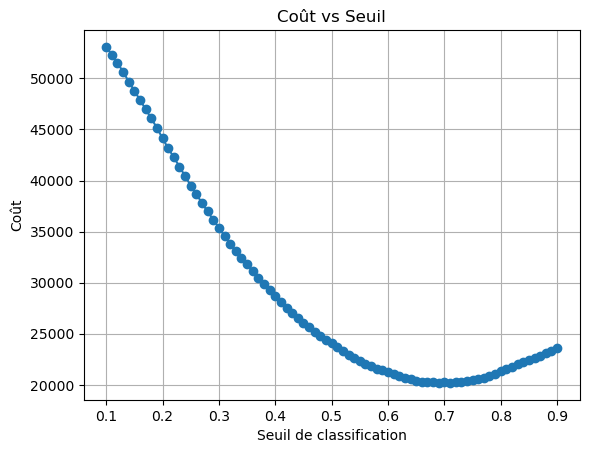

In [141]:
import matplotlib.pyplot as plt

plt.plot(thresholds, costs, marker='o')
plt.xlabel("Seuil de classification")
plt.ylabel("Coût")
plt.title("Coût vs Seuil")
plt.grid(True)
plt.show()

👉 On voit que le coût diminue fortement au début (0.1 → 0.7), atteint un minimum autour de 0.65 - 0.7, puis remonte ensuite.

Cela veut dire que le seuil "optimal" (au sens du coût métier défini) se situe dans cette zone.

In [146]:
import numpy as np

# Trouver l'index du coût minimal
best_idx = np.argmin(costs)
best_threshold = thresholds[best_idx]
best_cost = costs[best_idx]

print(f"🔎 Seuil optimal = {best_threshold:.2f}, avec un coût = {best_cost}")


🔎 Seuil optimal = 0.69, avec un coût = 20183


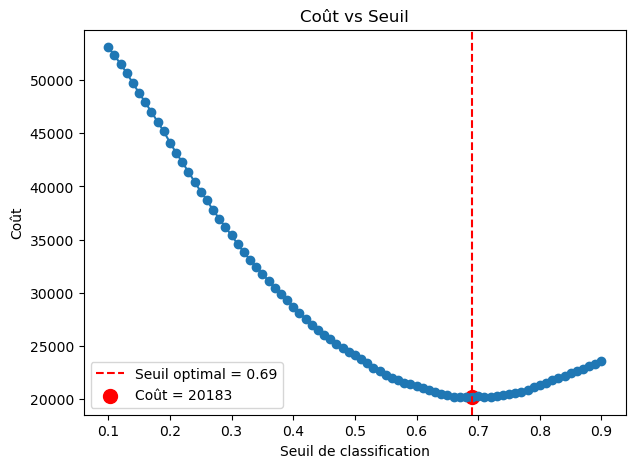

In [147]:
plt.figure(figsize=(7,5))
plt.plot(thresholds, costs, marker="o")
plt.title("Coût vs Seuil")
plt.xlabel("Seuil de classification")
plt.ylabel("Coût")

# Ajouter le point optimal
plt.axvline(x=best_threshold, color="red", linestyle="--", label=f"Seuil optimal = {best_threshold:.2f}")
plt.scatter(best_threshold, best_cost, color="red", s=100, label=f"Coût = {best_cost}")

plt.legend()
plt.show()


**Seuil optimal = 0.69**

C’est ici que le modèle équilibre le mieux les erreurs, en tenant compte le barème de coût fixé plus haut.

Le coût minimal atteint est 20183.

**Décision pratique :**

Si la probabilité prédite par le modèle est ≥ 0.69 → ***classé non solvable.***

Si elle est < 0.69 → ***classé solvable.***

🏦 **Interprétation métier (crédit bancaire)**

- En choisissant 0.69 comme seuil, on réduis le risque d’accorder un crédit à un mauvais payeur (faux négatif, très coûteux).

- On acceptes de refuser plus de bons clients (faux positifs), mais cela coûte moins cher globalement.

Choix stratégique : privilégier la sécurité financière (minimiser les pertes) plutôt que d’accepter un maximum de clients.